# NexaSat Digital Wallet: AI-Driven Customer Lifetime Value Prediction for Customer Analytics and Personalised Marketing

## Data Cleaning and Preprocessing

* **Data Quality Assessment**

  * Conducted an initial assessment of the NexaSat Digital Wallet dataset to understand its structure, dimensions, data types, and overall data quality.
  * Identified missing values, duplicate records, inconsistent data formats, and potential data quality issues.
  * Reviewed numerical and categorical variables to determine appropriate preprocessing techniques.

* **Data Cleaning**

  * Removed duplicate customer and transaction records to prevent repeated observations from influencing the analysis.
  * Identified and handled missing values using appropriate imputation strategies based on variable type and business context.
  * Standardised inconsistent categorical values, labels, and data formats.
  * Converted date and time variables into appropriate datetime formats to support transaction-level analysis and temporal feature engineering.
  * Reviewed numerical variables for invalid, extreme, or potentially erroneous observations.

* **Outlier Treatment**

  * Investigated extreme values in transaction amounts, transaction frequency, account activity, and other numerical variables.
  * Used statistical and visual techniques to distinguish genuine high-value customer behaviour from potential data-entry errors.
  * Applied appropriate outlier treatment where necessary while preserving legitimate customer behaviour, particularly high-value transactions relevant to CLV prediction.

* **Data Type Transformation**

  * Converted numerical variables into appropriate numeric data types for statistical analysis and machine learning.
  * Encoded categorical variables into machine-readable formats.
  * Ensured binary and categorical indicators were consistently represented across the dataset.

* **Target Variable Preparation**

  * Defined **Customer Lifetime Value (CLV)** as the target variable for the supervised machine learning problem.
  * Reviewed the distribution of CLV to identify skewness, extreme values, and potential modelling challenges.
  * Applied appropriate transformations where required to improve the suitability of the target variable for regression modelling.

* **Feature Preparation**

  * Selected relevant demographic, transactional, behavioural, and engagement variables for predictive modelling.
  * Removed irrelevant variables and identifiers that did not contribute meaningful predictive information.
  * Excluded variables that could introduce **data leakage**, ensuring that only information available at the appropriate prediction point was used.
  * Prepared the dataset for subsequent feature engineering and machine learning model development.

* **Feature Scaling and Encoding**

  * Applied appropriate encoding techniques to categorical variables to make them suitable for machine learning algorithms.
  * Scaled numerical features where required by algorithms sensitive to differences in feature magnitude.
  * Ensured that preprocessing transformations were applied consistently to training and testing datasets.

* **Data Splitting**

  * Divided the cleaned dataset into training and testing subsets to enable unbiased evaluation of model performance.
  * Ensured that preprocessing and feature transformations were fitted using the training data and subsequently applied to unseen testing data.

* **Final Data Validation**

  * Performed final checks to confirm that missing values, duplicates, inconsistent formats, and invalid observations had been appropriately addressed.
  * Verified that all variables required for modelling were in the correct format and contained valid values.
  * Produced a clean, structured modelling dataset ready for **exploratory data analysis, feature engineering, and Customer Lifetime Value prediction**.


# Import Required Libraries

In [8]:
# Import data manipulation libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations

# Import data visualization libraries
import plotly.express as px  # High-level interactive Plotly visualisations
import plotly.graph_objects as go  # Custom interactive Plotly charts
import seaborn as sns           # For enhanced statistical visualizations
import missingno as msno        # For visualisation of Missing Values
import os  # Provides tools for working with files and directories
from IPython.display import display  # Enables formatted DataFrame display in Jupyter


# LabelEncoder:
# Converts binary categorical variables into numerical values.

from sklearn.preprocessing import LabelEncoder


# OrdinalEncoder:
# Converts ordered categorical variables while preserving ranking.

from sklearn.preprocessing import OrdinalEncoder


# OneHotEncoder:
# Converts nominal categorical variables into binary indicator columns.

from sklearn.preprocessing import OneHotEncoder


# SimpleImputer:
# Handles missing values before encoding.

from sklearn.impute import SimpleImputer


# Pipeline:
# Allows multiple preprocessing steps to be combined.

from sklearn.pipeline import Pipeline


# ColumnTransformer:
# Applies different preprocessing methods to different columns.

from sklearn.compose import ColumnTransformer

import warnings  # Provides tools for managing Python warning messages

warnings.filterwarnings("ignore")  # Suppresses warning messages during execution

# Data Import and Inspections

In [2]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# DATA CLEANING AND PREPROCESSING
# =============================================================================
#
# STAGE 1: AUTOMATED DATA LOADING AND INITIAL DATA INSPECTION
# =============================================================================




# =============================================================================
# 1. DATASET CONFIGURATION
# =============================================================================

DATASET_PATH = "digital_wallet_ltv.csv"

TARGET_VARIABLE = "LTV"

ID_VARIABLE = "Customer_ID"


# =============================================================================
# 2. EXPECTED DATASET SCHEMA
# =============================================================================

EXPECTED_COLUMNS = [
    "Customer_ID",
    "Age",
    "Location",
    "Income_Level",
    "Total_Transactions",
    "Avg_Transaction_Value",
    "Max_Transaction_Value",
    "Min_Transaction_Value",
    "Total_Spent",
    "Active_Days",
    "Last_Transaction_Days_Ago",
    "Loyalty_Points_Earned",
    "Referral_Count",
    "Cashback_Received",
    "App_Usage_Frequency",
    "Preferred_Payment_Method",
    "Support_Tickets_Raised",
    "Issue_Resolution_Time",
    "Customer_Satisfaction_Score",
    "LTV"
]


# =============================================================================
# 3. AUTOMATED DATA LOADING AND INITIAL INSPECTION
# =============================================================================

def load_and_inspect_dataset(file_path=DATASET_PATH):

    """
    Load, validate and initially inspect the NexaSat Digital Wallet
    Customer Lifetime Value dataset.

    Parameters
    ----------
    file_path : str
        Path to the digital wallet LTV CSV dataset.

    Returns
    -------
    pandas.DataFrame
        Loaded raw dataset.
    """


    # =========================================================================
    # STEP 1: VALIDATE DATASET PATH
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET - DATA LOADING PIPELINE")
    print("=" * 80)

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"Dataset not found: '{file_path}'. "
            "Please confirm that the file exists in the current "
            "working directory."
        )

    print(f"\nDataset located successfully: {file_path}")


    # =========================================================================
    # STEP 2: LOAD RAW DATASET
    # =========================================================================

    df = pd.read_csv(file_path)

    print("\nDataset successfully imported.")
    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]:,}")


    # =========================================================================
    # STEP 3: VALIDATE DATASET SCHEMA
    # =========================================================================

    actual_columns = df.columns.tolist()

    missing_columns = [
        column
        for column in EXPECTED_COLUMNS
        if column not in actual_columns
    ]

    unexpected_columns = [
        column
        for column in actual_columns
        if column not in EXPECTED_COLUMNS
    ]


    print("\n" + "=" * 80)
    print("DATASET SCHEMA VALIDATION")
    print("=" * 80)

    if missing_columns:

        print("\nMissing Expected Columns:")

        for column in missing_columns:
            print(f"  - {column}")

    else:

        print("\nAll expected columns are present.")


    if unexpected_columns:

        print("\nUnexpected Columns Detected:")

        for column in unexpected_columns:
            print(f"  - {column}")

    else:

        print("No unexpected columns detected.")


    # Validate critical variables

    if TARGET_VARIABLE not in df.columns:

        raise ValueError(
            f"Target variable '{TARGET_VARIABLE}' "
            "is missing from the dataset."
        )


    if ID_VARIABLE not in df.columns:

        raise ValueError(
            f"Identifier variable '{ID_VARIABLE}' "
            "is missing from the dataset."
        )


    # =========================================================================
    # STEP 4: INITIAL DATA PREVIEW
    # =========================================================================

    print("\n" + "=" * 80)
    print("FIRST 5 CUSTOMER RECORDS")
    print("=" * 80)

    display(df.head())


    print("\n" + "=" * 80)
    print("LAST 5 CUSTOMER RECORDS")
    print("=" * 80)

    display(df.tail())


    # =========================================================================
    # STEP 5: DATASET INFORMATION
    # =========================================================================

    print("\n" + "=" * 80)
    print("DATASET INFORMATION")
    print("=" * 80)

    df.info()


    # =========================================================================
    # STEP 6: DATASET DIMENSIONS
    # =========================================================================

    print("\n" + "=" * 80)
    print("DATASET DIMENSIONS")
    print("=" * 80)

    rows, columns = df.shape

    print(f"\nNumber of Customer Records : {rows:,}")
    print(f"Number of Variables        : {columns:,}")


    # =========================================================================
    # STEP 7: COLUMN INVENTORY
    # =========================================================================

    print("\n" + "=" * 80)
    print("DATASET COLUMN INVENTORY")
    print("=" * 80)

    column_inventory = pd.DataFrame({
        "Column_Number": range(1, len(df.columns) + 1),
        "Column_Name": df.columns,
        "Data_Type": df.dtypes.astype(str).values,
        "Non_Null_Count": df.notna().sum().values,
        "Missing_Count": df.isna().sum().values
    })

    column_inventory["Missing_Percentage"] = (
        column_inventory["Missing_Count"]
        / len(df)
        * 100
    ).round(2)

    display(column_inventory)


    # =========================================================================
    # STEP 8: MISSING VALUE ASSESSMENT
    # =========================================================================

    print("\n" + "=" * 80)
    print("MISSING VALUE ASSESSMENT")
    print("=" * 80)

    missing_summary = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_Percentage": (
            df.isna().mean() * 100
        ).round(2)
    })

    missing_summary = (
        missing_summary
        .sort_values(
            by="Missing_Count",
            ascending=False
        )
    )

    display(missing_summary)


    # =========================================================================
    # STEP 9: DUPLICATE RECORD ASSESSMENT
    # =========================================================================

    print("\n" + "=" * 80)
    print("DUPLICATE RECORD ASSESSMENT")
    print("=" * 80)

    duplicate_count = df.duplicated().sum()

    print(f"\nComplete Duplicate Rows: {duplicate_count:,}")


    # =========================================================================
    # STEP 10: CUSTOMER ID VALIDATION
    # =========================================================================

    print("\n" + "=" * 80)
    print("CUSTOMER ID VALIDATION")
    print("=" * 80)

    unique_customer_ids = df[ID_VARIABLE].nunique()
    duplicate_customer_ids = df[ID_VARIABLE].duplicated().sum()

    print(f"\nTotal Records          : {len(df):,}")
    print(f"Unique Customer IDs    : {unique_customer_ids:,}")
    print(f"Duplicate Customer IDs : {duplicate_customer_ids:,}")


    # =========================================================================
    # STEP 11: TARGET VARIABLE INSPECTION
    # =========================================================================

    print("\n" + "=" * 80)
    print("TARGET VARIABLE: LTV")
    print("=" * 80)

    print(f"\nData Type:")
    print(df[TARGET_VARIABLE].dtype)

    print(f"\nMissing Values:")
    print(df[TARGET_VARIABLE].isna().sum())

    print("\nLTV Summary Statistics:")

    display(
        df[TARGET_VARIABLE]
        .describe()
        .to_frame(name=TARGET_VARIABLE)
    )


    # =========================================================================
    # STEP 12: FEATURE TYPE IDENTIFICATION
    # =========================================================================

    print("\n" + "=" * 80)
    print("FEATURE TYPE IDENTIFICATION")
    print("=" * 80)

    numerical_features = df.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_features = df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()


    print("\nNumerical Variables:")

    for feature in numerical_features:
        print(f"  - {feature}")


    print("\nCategorical Variables:")

    for feature in categorical_features:
        print(f"  - {feature}")


    # =========================================================================
    # STEP 13: MODELLING VARIABLE STRUCTURE
    # =========================================================================

    predictor_features = [
        column
        for column in df.columns
        if column not in [ID_VARIABLE, TARGET_VARIABLE]
    ]


    print("\n" + "=" * 80)
    print("MODELLING VARIABLE STRUCTURE")
    print("=" * 80)

    print(f"\nIdentifier Variable:")
    print(f"  {ID_VARIABLE}")

    print(f"\nTarget Variable:")
    print(f"  {TARGET_VARIABLE}")

    print(f"\nPredictor Variables ({len(predictor_features)}):")

    for feature in predictor_features:
        print(f"  - {feature}")


    # =========================================================================
    # STEP 14: INITIAL DATA QUALITY SUMMARY
    # =========================================================================

    print("\n" + "=" * 80)
    print("INITIAL DATA QUALITY SUMMARY")
    print("=" * 80)

    print(f"""
Dataset File             : {file_path}
Customer Records         : {len(df):,}
Variables                : {len(df.columns):,}
Target Variable          : {TARGET_VARIABLE}
Identifier Variable      : {ID_VARIABLE}
Complete Duplicate Rows  : {duplicate_count:,}
Duplicate Customer IDs   : {duplicate_customer_ids:,}
Total Missing Values     : {df.isna().sum().sum():,}
Numerical Variables      : {len(numerical_features)}
Categorical Variables    : {len(categorical_features)}
""")


    # =========================================================================
    # STEP 15: RETURN RAW DATASET
    # =========================================================================
    #
    # No cleaning or transformation is performed at this stage.
    # The raw dataset is returned for the dedicated cleaning and preprocessing
    # stage.
    #
    # =========================================================================

    return df


# =============================================================================
# EXECUTE PIPELINE
# =============================================================================

df = load_and_inspect_dataset(DATASET_PATH)


# =============================================================================
# NEXT PIPELINE STAGE
# =============================================================================
#
# Data Cleaning and Preprocessing:
#
# 1. Missing-value treatment
# 2. Duplicate treatment
# 3. Data-type validation
# 4. Outlier assessment
# 5. Categorical encoding
# 6. Numerical feature transformation
# 7. Data leakage assessment
# 8. Final modelling dataset preparation
#
# =============================================================================

NEXASAT DIGITAL WALLET - DATA LOADING PIPELINE

Dataset located successfully: digital_wallet_ltv.csv

Dataset successfully imported.
Rows    : 7,000
Columns : 20

DATASET SCHEMA VALIDATION

All expected columns are present.
No unexpected columns detected.

FIRST 5 CUSTOMER RECORDS


,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.38402,60216.83451,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.73468,48350.10027,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.37280,32521.15719,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.87645,17827.89672,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.09266,17497.63453,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05



LAST 5 CUSTOMER RECORDS


,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
6995,cust_6995,68,Suburban,High,340,162.703503,605.997495,80.352666,5.531919e+04,78,20,521,32,654.218655,Monthly,Credit Card,14,3.351374,3,1.244681e+04
6996,cust_6996,62,Suburban,High,647,1575.707877,4702.522747,359.511332,1.019483e+06,271,252,2972,40,3574.857418,Monthly,Wallet Balance,13,19.735330,3,1.131049e+05
6997,cust_6997,16,Urban,Middle,481,14429.355180,17207.737630,1510.598329,6.940520e+06,225,348,2423,8,2899.068571,Monthly,UPI,12,45.036932,2,7.002484e+05
6998,cust_6998,32,Urban,High,574,8005.027184,33203.795720,1976.326124,4.594886e+06,121,50,634,31,2432.363200,Monthly,Credit Card,11,44.145749,1,4.636404e+05
6999,cust_6999,17,Suburban,Middle,825,15697.668870,50584.163430,7833.230956,1.295058e+07,223,189,648,12,638.252000,Monthly,Credit Card,17,35.113661,1,1.298235e+06



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  7000 non-null   str    
 1   Age                          7000 non-null   int64  
 2   Location                     7000 non-null   str    
 3   Income_Level                 7000 non-null   str    
 4   Total_Transactions           7000 non-null   int64  
 5   Avg_Transaction_Value        7000 non-null   float64
 6   Max_Transaction_Value        7000 non-null   float64
 7   Min_Transaction_Value        7000 non-null   float64
 8   Total_Spent                  7000 non-null   float64
 9   Active_Days                  7000 non-null   int64  
 10  Last_Transaction_Days_Ago    7000 non-null   int64  
 11  Loyalty_Points_Earned        7000 non-null   int64  
 12  Referral_Count               7000 non-null   int64  
 13  Cashback

...


MISSING VALUE ASSESSMENT


,Missing_Count,Missing_Percentage
Customer_ID,0,0.0
Age,0,0.0
Location,0,0.0
Income_Level,0,0.0
Total_Transactions,0,0.0
Avg_Transaction_Value,0,0.0
Max_Transaction_Value,0,0.0
Min_Transaction_Value,0,0.0
Total_Spent,0,0.0
Active_Days,0,0.0



DUPLICATE RECORD ASSESSMENT

Complete Duplicate Rows: 0

CUSTOMER ID VALIDATION

Total Records          : 7,000
Unique Customer IDs    : 7,000
Duplicate Customer IDs : 0

TARGET VARIABLE: LTV

Data Type:
float64

Missing Values:
0

LTV Summary Statistics:


,LTV
count,7.000000e+03
mean,5.119197e+05
std,4.390551e+05
min,3.770495e+03
25%,1.482058e+05
50%,3.878180e+05
75%,7.748578e+05
max,1.956988e+06



FEATURE TYPE IDENTIFICATION

Numerical Variables:
  - Age
  - Total_Transactions
  - Avg_Transaction_Value
  - Max_Transaction_Value
  - Min_Transaction_Value
  - Total_Spent
  - Active_Days
  - Last_Transaction_Days_Ago
  - Loyalty_Points_Earned
  - Referral_Count
  - Cashback_Received
  - Support_Tickets_Raised
  - Issue_Resolution_Time
  - Customer_Satisfaction_Score
  - LTV

Categorical Variables:
  - Customer_ID
  - Location
  - Income_Level
  - App_Usage_Frequency
  - Preferred_Payment_Method

MODELLING VARIABLE STRUCTURE

Identifier Variable:
  Customer_ID

Target Variable:
  LTV

Predictor Variables (18):
  - Age
  - Location
  - Income_Level
  - Total_Transactions
  - Avg_Transaction_Value
  - Max_Transaction_Value
  - Min_Transaction_Value
  - Total_Spent
  - Active_Days
  - Last_Transaction_Days_Ago
  - Loyalty_Points_Earned
  - Referral_Count
  - Cashback_Received
  - App_Usage_Frequency
  - Preferred_Payment_Method
  - Support_Tickets_Raised
  - Issue_Resolution_Time
  - 

# Investigating Descripancies in Categorical Variables

In [3]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED CATEGORICAL VARIABLE UNIQUENESS ANALYSIS PIPELINE
# =============================================================================
#
# Objective:
# Automatically identify categorical variables in the NexaSat Digital Wallet
# customer dataset and analyse their unique categories before encoding.
#
# The analysis helps determine:
#
# - Which variables require categorical encoding
# - The number of categories in each variable
# - Whether variables have low or high cardinality
# - Whether unexpected categories exist
# - Whether missing values require treatment
# - The most appropriate encoding strategy
#
# Dataset:
# digital_wallet_ltv.csv
#
# Categorical Variables Expected:
#
# Location
# Income_Level
# Preferred_Payment_Method
#
# Variables excluded from categorical analysis:
#
# Customer_ID → Customer identifier
# LTV         → Target variable
#
# Workflow:
#
# Raw Dataset
#      ↓
# Identify Categorical Features
#      ↓
# Calculate Unique Categories
#      ↓
# Assess Missing Values
#      ↓
# Review Category Distribution
#      ↓
# Assess Cardinality
#      ↓
# Select Encoding Strategy
#      ↓
# Prepare Data for Machine Learning
#
# =============================================================================


def analyse_categorical_variables(
    df,
    target_variable="LTV",
    id_variable="Customer_ID"
):

    """
    Analyse categorical variables in the NexaSat Digital Wallet dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Input NexaSat Digital Wallet customer dataset.

    target_variable : str, default="LTV"
        Target variable that should be excluded from categorical
        predictor analysis.

    id_variable : str, default="Customer_ID"
        Customer identifier that should be excluded from modelling
        feature analysis.

    Returns
    -------
    categorical_summary : pandas.DataFrame
        Summary of categorical variables, including:
        - Feature name
        - Data type
        - Unique category count
        - Missing values
        - Missing percentage
        - Category values
        - Cardinality classification
    """


    # =========================================================================
    # STEP 1: IDENTIFY CATEGORICAL VARIABLES
    # =========================================================================
    #
    # Automatically identify text-based categorical variables.
    #
    # Customer_ID and LTV are explicitly excluded because:
    #
    # Customer_ID → Identifier rather than a predictive feature
    # LTV         → Continuous target variable
    #
    # =========================================================================

    categorical_columns = df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()


    categorical_columns = [
        column
        for column in categorical_columns
        if column not in [id_variable, target_variable]
    ]


    # =========================================================================
    # STEP 2: CHECK FOR CATEGORICAL VARIABLES
    # =========================================================================

    if not categorical_columns:

        print("No categorical variables were identified.")

        return pd.DataFrame()


    # =========================================================================
    # STEP 3: CALCULATE CATEGORICAL VARIABLE SUMMARY
    # =========================================================================
    #
    # For each categorical variable, calculate:
    #
    # - Number of unique categories
    # - Number of missing observations
    # - Percentage of missing observations
    # - Actual category values
    #
    # =========================================================================

    categorical_results = []


    for column in categorical_columns:

        unique_count = df[column].nunique(
            dropna=True
        )

        missing_count = df[column].isna().sum()

        missing_percentage = (
            df[column].isna().mean() * 100
        )


        # Identify cardinality level
        if unique_count <= 10:

            cardinality = "Low"

        elif unique_count <= 50:

            cardinality = "Medium"

        else:

            cardinality = "High"


        # Extract available category values
        unique_values = (
            df[column]
            .dropna()
            .unique()
            .tolist()
        )


        categorical_results.append({

            "Feature": column,

            "Data_Type": str(df[column].dtype),

            "Unique_Count": unique_count,

            "Missing_Count": missing_count,

            "Missing_Percentage": round(
                missing_percentage,
                2
            ),

            "Cardinality": cardinality,

            "Unique_Values": unique_values
        })


    # =========================================================================
    # STEP 4: CREATE SUMMARY DATAFRAME
    # =========================================================================

    categorical_summary = pd.DataFrame(
        categorical_results
    )


    # =========================================================================
    # STEP 5: SORT VARIABLES BY CARDINALITY
    # =========================================================================

    categorical_summary = categorical_summary.sort_values(
        by="Unique_Count",
        ascending=True
    ).reset_index(drop=True)


    # =========================================================================
    # STEP 6: DISPLAY ANALYSIS RESULTS
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET")
    print("CATEGORICAL VARIABLE UNIQUENESS ANALYSIS")
    print("=" * 80)


    print("\nCategorical Variables Identified:")

    for column in categorical_columns:
        print(f"  - {column}")


    print("\nCategorical Variable Summary:")

    display(categorical_summary)


    # =========================================================================
    # STEP 7: DISPLAY CATEGORY DISTRIBUTIONS
    # =========================================================================
    #
    # Display the frequency distribution of each categorical variable.
    #
    # This helps identify:
    #
    # - Dominant categories
    # - Rare categories
    # - Unexpected values
    # - Potential data quality problems
    #
    # =========================================================================

    print("\n" + "=" * 80)
    print("CATEGORY FREQUENCY DISTRIBUTIONS")
    print("=" * 80)


    for column in categorical_columns:

        print(f"\n{column}")

        category_distribution = (
            df[column]
            .value_counts(
                dropna=False
            )
            .rename_axis(column)
            .reset_index(
                name="Count"
            )
        )


        category_distribution["Percentage"] = (
            category_distribution["Count"]
            / len(df)
            * 100
        ).round(2)


        display(category_distribution)


    # =========================================================================
    # STEP 8: ENCODING CONSIDERATION
    # =========================================================================
    #
    # Provide an initial recommendation based on cardinality.
    #
    # These are preliminary recommendations. The final encoding strategy
    # should also consider whether a variable is nominal or ordinal.
    #
    # =========================================================================

    print("\n" + "=" * 80)
    print("INITIAL ENCODING CONSIDERATIONS")
    print("=" * 80)


    for _, row in categorical_summary.iterrows():

        feature = row["Feature"]
        cardinality = row["Cardinality"]
        unique_count = row["Unique_Count"]


        if cardinality == "Low":

            recommendation = (
                "One-Hot Encoding likely appropriate"
            )

        elif cardinality == "Medium":

            recommendation = (
                "Review category distribution before encoding"
            )

        else:

            recommendation = (
                "Consider alternative encoding or category grouping"
            )


        print(
            f"\n{feature}: "
            f"{unique_count} categories → "
            f"{recommendation}"
        )


    # =========================================================================
    # STEP 9: RETURN RESULTS
    # =========================================================================

    return categorical_summary


# =============================================================================
# EXECUTE CATEGORICAL VARIABLE ANALYSIS PIPELINE
# =============================================================================

categorical_summary = analyse_categorical_variables(
    df,
    target_variable="LTV",
    id_variable="Customer_ID"
)

NEXASAT DIGITAL WALLET
CATEGORICAL VARIABLE UNIQUENESS ANALYSIS

Categorical Variables Identified:
  - Location
  - Income_Level
  - App_Usage_Frequency
  - Preferred_Payment_Method

Categorical Variable Summary:


,Feature,Data_Type,Unique_Count,Missing_Count,Missing_Percentage,Cardinality,Unique_Values
0,Location,str,3,0,0.0,Low,"[Urban, Suburban, Rural]"
1,Income_Level,str,3,0,0.0,Low,"[Low, High, Middle]"
2,App_Usage_Frequency,str,3,0,0.0,Low,"[Monthly, Weekly, Daily]"
3,Preferred_Payment_Method,str,4,0,0.0,Low,"[Debit Card, UPI, Wallet Balance, Credit Card]"



CATEGORY FREQUENCY DISTRIBUTIONS

Location


,Location,Count,Percentage
0,Urban,2368,33.83
1,Suburban,2320,33.14
2,Rural,2312,33.03



Income_Level


...


App_Usage_Frequency


,App_Usage_Frequency,Count,Percentage
0,Daily,2346,33.51
1,Monthly,2329,33.27
2,Weekly,2325,33.21



Preferred_Payment_Method


,Preferred_Payment_Method,Count,Percentage
0,UPI,1791,25.59
1,Debit Card,1761,25.16
2,Wallet Balance,1736,24.80
3,Credit Card,1712,24.46



INITIAL ENCODING CONSIDERATIONS

Location: 3 categories → One-Hot Encoding likely appropriate

Income_Level: 3 categories → One-Hot Encoding likely appropriate

App_Usage_Frequency: 3 categories → One-Hot Encoding likely appropriate

Preferred_Payment_Method: 4 categories → One-Hot Encoding likely appropriate


# Remove Unwanted Columns

In [4]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED IDENTIFIER COLUMN REMOVAL PIPELINE
# =============================================================================
#
# Objective:
# Remove non-predictive customer identifier columns from the NexaSat Digital
# Wallet dataset before exploratory data analysis, feature engineering and
# Customer Lifetime Value (LTV) model development.
#
# Identifier variables uniquely identify customers but do not represent
# meaningful behavioural, transactional or customer-value characteristics.
#
# Retaining identifiers during model development may:
#
# - Introduce irrelevant information
# - Increase model complexity
# - Increase the risk of overfitting
# - Reduce model interpretability
# - Potentially create spurious relationships
#
# Important:
# Customer_ID is retained in the original raw dataset for customer-level
# identification and reporting, but it is removed from the modelling dataset.
#
# Workflow:
#
# Raw Customer Dataset
#        ↓
# Identify Identifier Columns
#        ↓
# Validate Column Existence
#        ↓
# Remove Identifier Columns
#        ↓
# Validate Target Variable
#        ↓
# Return Modelling Dataset
#
# =============================================================================


def drop_identifier_columns(
    dataframe: pd.DataFrame,
    identifier_columns=None,
    target_variable="LTV"
) -> pd.DataFrame:

    """
    Remove non-predictive identifier columns from the NexaSat Digital Wallet
    dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input NexaSat Digital Wallet customer dataset.

    identifier_columns : list, optional
        List of identifier columns to remove.
        Default is ["Customer_ID"].

    target_variable : str, default="LTV"
        Target variable for Customer Lifetime Value prediction.

    Returns
    -------
    pandas.DataFrame
        Dataset with identifier columns removed while retaining the LTV target.
    """


    # =========================================================================
    # STEP 1: DEFINE IDENTIFIER COLUMNS
    # =========================================================================
    #
    # Customer_ID uniquely identifies each customer but does not represent
    # customer behaviour or financial value.
    #
    # It should therefore not be used as a predictive feature.
    #
    # =========================================================================

    if identifier_columns is None:

        identifier_columns = [
            "Customer_ID"
        ]


    # =========================================================================
    # STEP 2: VALIDATE INPUT DATAFRAME
    # =========================================================================
    #
    # Confirm that the supplied object is a pandas DataFrame.
    #
    # =========================================================================

    if not isinstance(dataframe, pd.DataFrame):

        raise TypeError(
            "Input must be a pandas DataFrame."
        )


    # =========================================================================
    # STEP 3: VALIDATE TARGET VARIABLE
    # =========================================================================
    #
    # LTV is the target variable for the NexaSat Customer Lifetime Value
    # prediction model.
    #
    # It must remain in the dataset at this stage.
    #
    # =========================================================================

    if target_variable not in dataframe.columns:

        raise ValueError(
            f"Target variable '{target_variable}' "
            "was not found in the dataset."
        )


    # =========================================================================
    # STEP 4: IDENTIFY EXISTING IDENTIFIER COLUMNS
    # =========================================================================
    #
    # Only remove identifier columns that are actually present.
    #
    # This prevents errors if the function is executed more than once or
    # if the dataset structure changes.
    #
    # =========================================================================

    existing_columns = [
        column
        for column in identifier_columns
        if column in dataframe.columns
    ]


    # =========================================================================
    # STEP 5: CAPTURE ORIGINAL DATASET DIMENSIONS
    # =========================================================================

    original_shape = dataframe.shape


    # =========================================================================
    # STEP 6: REMOVE IDENTIFIER COLUMNS
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET")
    print("IDENTIFIER COLUMN REMOVAL")
    print("=" * 80)


    if existing_columns:

        dataframe = dataframe.drop(
            columns=existing_columns
        )

        print(
            f"\nIdentifier Columns Removed: "
            f"{existing_columns}"
        )

    else:

        print("\nNo identifier columns found.")


    # =========================================================================
    # STEP 7: DISPLAY DATASET DIMENSION CHANGES
    # =========================================================================

    updated_shape = dataframe.shape

    print("\nDataset Dimensions:")

    print(
        f"Before Removal : "
        f"{original_shape[0]:,} rows × "
        f"{original_shape[1]:,} columns"
    )

    print(
        f"After Removal  : "
        f"{updated_shape[0]:,} rows × "
        f"{updated_shape[1]:,} columns"
    )


    # =========================================================================
    # STEP 8: VALIDATE TARGET VARIABLE
    # =========================================================================
    #
    # Confirm that LTV remains available after identifier removal.
    #
    # =========================================================================

    if target_variable in dataframe.columns:

        print(
            f"\nTarget Variable '{target_variable}': "
            "Successfully retained"
        )

    else:

        raise ValueError(
            f"Target variable '{target_variable}' "
            "was unexpectedly removed."
        )


    # =========================================================================
    # STEP 9: DISPLAY REMAINING VARIABLES
    # =========================================================================
    #
    # The remaining columns consist of candidate predictors and the LTV target.
    #
    # =========================================================================

    print("\nRemaining Dataset Columns:")

    for number, column in enumerate(
        dataframe.columns,
        start=1
    ):

        print(
            f"{number:02d}. {column}"
        )


    # =========================================================================
    # STEP 10: RETURN MODELLING DATASET
    # =========================================================================
    #
    # Return the updated dataframe for subsequent stages:
    #
    # - Missing Value Treatment
    # - Duplicate Analysis
    # - Outlier Analysis
    # - Categorical Encoding
    # - Feature Engineering
    # - Feature Selection
    # - LTV Model Development
    #
    # =========================================================================

    return dataframe


# =============================================================================
# EXECUTE IDENTIFIER COLUMN REMOVAL PIPELINE
# =============================================================================

df = drop_identifier_columns(
    df,
    identifier_columns=["Customer_ID"],
    target_variable="LTV"
)

NEXASAT DIGITAL WALLET
IDENTIFIER COLUMN REMOVAL

Identifier Columns Removed: ['Customer_ID']

Dataset Dimensions:
Before Removal : 7,000 rows × 20 columns
After Removal  : 7,000 rows × 19 columns

Target Variable 'LTV': Successfully retained

Remaining Dataset Columns:
01. Age
02. Location
03. Income_Level
04. Total_Transactions
05. Avg_Transaction_Value
06. Max_Transaction_Value
07. Min_Transaction_Value
08. Total_Spent
09. Active_Days
10. Last_Transaction_Days_Ago
11. Loyalty_Points_Earned
12. Referral_Count
13. Cashback_Received
14. App_Usage_Frequency
15. Preferred_Payment_Method
16. Support_Tickets_Raised
17. Issue_Resolution_Time
18. Customer_Satisfaction_Score
19. LTV


# Investigating and Handling Missing Values

In [5]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED MISSING VALUE ANALYSIS PIPELINE
# =============================================================================
#
# Objective:
# -----------------------------------------------------------------------------
# This pipeline automatically identifies, quantifies, and summarises missing
# values within the NexaSat Digital Wallet customer dataset.
#
# Missing-value analysis is an important component of data cleaning because
# incomplete observations can affect:
#
# - Statistical analysis
# - Exploratory Data Analysis (EDA)
# - Feature engineering
# - Machine learning model training
# - Customer Lifetime Value (LTV) predictions
#
# Importantly, this pipeline ONLY analyses missing values.
# It does NOT perform imputation or remove observations.
#
# This separation is intentional because the appropriate treatment depends on:
#
# - The variable type
# - The percentage of missing observations
# - The business meaning of the variable
# - Whether the variable is a predictor or target
#
#
# Workflow:
#
# Digital Wallet Customer Dataset
#              ↓
#      Validate Input Dataset
#              ↓
#       Detect Missing Values
#              ↓
#       Count Missing Values
#              ↓
#    Calculate Missing Percentage
#              ↓
#     Calculate Data Completeness
#              ↓
#       Generate Quality Report
#              ↓
#    Determine Treatment Strategy
#
# =============================================================================


def analyse_missing_values(
    dataframe: pd.DataFrame
) -> pd.DataFrame:

    """
    Perform an automated missing-value assessment for the NexaSat Digital
    Wallet Customer Lifetime Value (LTV) dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input NexaSat Digital Wallet customer dataset.

    Returns
    -------
    pandas.DataFrame
        Summary table containing variables with missing observations,
        missing-value counts, available observations, and missing percentages.

    Notes
    -----
    This function does not modify the original dataset.

    It only identifies and reports missing values so that an appropriate
    treatment strategy can be applied during the subsequent preprocessing
    stage.
    """


    # =========================================================================
    # STEP 1: VALIDATE INPUT DATASET
    # =========================================================================
    #
    # Purpose:
    # Confirm that the object supplied to the function is a pandas DataFrame.
    #
    # Why this matters:
    # ---------------------------------------------------------
    # The pipeline uses pandas DataFrame methods such as:
    #
    # - isnull()
    # - sum()
    # - shape
    # - columns
    #
    # If another Python object is accidentally supplied, the pipeline should
    # stop immediately and provide a clear error message.
    #
    # =========================================================================

    if not isinstance(dataframe, pd.DataFrame):

        raise TypeError(
            "Input must be a pandas DataFrame."
        )


    # =========================================================================
    # STEP 2: CALCULATE MISSING VALUE COUNT
    # =========================================================================
    #
    # Purpose:
    # Determine the number of missing observations in every variable.
    #
    # isnull():
    # ---------------------------------------------------------
    # Returns True when an observation is missing and False otherwise.
    #
    # sum():
    # ---------------------------------------------------------
    # Treats True as 1 and False as 0, allowing us to count the missing
    # observations for each column.
    #
    # Example:
    #
    # Age
    # ----------------
    # 35
    # 42
    # NaN
    # 51
    #
    # Missing count = 1
    #
    # =========================================================================

    missing_count = dataframe.isnull().sum()


    # =========================================================================
    # STEP 3: CALCULATE MISSING VALUE PERCENTAGE
    # =========================================================================
    #
    # Purpose:
    # Convert the raw missing-value count into a percentage of the total
    # customer records.
    #
    # Formula:
    #
    # Missing Percentage =
    #
    # (Number of Missing Values / Total Number of Records) × 100
    #
    # Why percentage is important:
    # ---------------------------------------------------------
    # A raw missing count alone does not show the severity of the problem.
    #
    # For example:
    #
    # Dataset A:
    # 100 missing values out of 100,000 records = 0.1%
    #
    # Dataset B:
    # 100 missing values out of 500 records = 20%
    #
    # The percentage provides better context for deciding whether a variable
    # requires imputation, investigation, or possible removal.
    #
    # =========================================================================

    missing_percentage = (
        missing_count
        / len(dataframe)
        * 100
    ).round(2)


    # =========================================================================
    # STEP 4: CREATE MISSING VALUE SUMMARY TABLE
    # =========================================================================
    #
    # Purpose:
    # Combine the missing-value statistics into a structured DataFrame.
    #
    # The report contains:
    #
    # Feature
    # ---------------------------------------------------------
    # Name of the dataset variable.
    #
    # Missing_Values
    # ---------------------------------------------------------
    # Number of missing observations.
    #
    # Missing_Percentage (%)
    # ---------------------------------------------------------
    # Percentage of observations that are missing.
    #
    # This structured format makes the results easier to inspect, export,
    # document, and use in later preprocessing decisions.
    #
    # =========================================================================

    missing_summary = pd.DataFrame({

        "Feature": dataframe.columns,

        "Missing_Values": missing_count.values,

        "Missing_Percentage (%)": missing_percentage.values

    })


    # =========================================================================
    # STEP 5: CALCULATE AVAILABLE OBSERVATIONS
    # =========================================================================
    #
    # Purpose:
    # Calculate the number of non-missing observations available for each
    # variable.
    #
    # Formula:
    #
    # Available Values =
    #
    # Total Records - Missing Values
    #
    # This provides an additional perspective on the completeness of each
    # customer attribute.
    #
    # Example:
    #
    # If the dataset contains 10,000 customers and Age has 50 missing values:
    #
    # Available Age Values = 10,000 - 50 = 9,950
    #
    # =========================================================================

    missing_summary["Available_Values"] = (
        len(dataframe)
        - missing_summary["Missing_Values"]
    )


    # =========================================================================
    # STEP 6: IDENTIFY VARIABLES CONTAINING MISSING VALUES
    # =========================================================================
    #
    # Purpose:
    # Focus the detailed report only on variables that actually contain
    # missing observations.
    #
    # Variables with zero missing values do not require immediate missing-value
    # treatment, so removing them from the detailed report makes the analysis
    # easier to interpret.
    #
    # The report is sorted in descending order so that the variables with the
    # greatest number of missing observations appear first.
    #
    # =========================================================================

    missing_summary = (

        missing_summary

        .loc[
            missing_summary["Missing_Values"] > 0
        ]

        .sort_values(
            by="Missing_Values",
            ascending=False
        )

        .reset_index(drop=True)

    )


    # =========================================================================
    # STEP 7: CALCULATE OVERALL DATASET MISSINGNESS
    # =========================================================================
    #
    # Purpose:
    # Calculate the total amount of missing data across the entire dataset.
    #
    # Total cells:
    #
    #     Number of rows × Number of columns
    #
    # Overall Missing Percentage:
    #
    #     Total Missing Cells / Total Dataset Cells × 100
    #
    # This provides a high-level view of the overall completeness of the
    # NexaSat Digital Wallet dataset.
    #
    # =========================================================================

    total_records = len(dataframe)

    total_missing = (
        dataframe.isnull()
        .sum()
        .sum()
    )

    total_cells = (
        dataframe.shape[0]
        * dataframe.shape[1]
    )

    overall_missing_percentage = (
        total_missing
        / total_cells
        * 100
    ).round(2)


    # =========================================================================
    # STEP 8: DISPLAY MISSING VALUE ANALYSIS REPORT
    # =========================================================================
    #
    # Purpose:
    # Present the results in a clear format for data-quality assessment.
    #
    # The report provides:
    #
    # - Total number of customer records
    # - Total missing values
    # - Overall missing percentage
    # - Number of variables affected by missing values
    #
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET")
    print("MISSING VALUE ANALYSIS REPORT")
    print("=" * 80)

    print(
        f"\nTotal Customer Records: "
        f"{total_records:,}"
    )

    print(
        f"Total Missing Values: "
        f"{total_missing:,}"
    )

    print(
        f"Overall Missing Percentage: "
        f"{overall_missing_percentage}%"
    )

    print(
        f"Variables Affected: "
        f"{len(missing_summary)}"
    )


    # =========================================================================
    # STEP 9: DISPLAY DETAILED MISSING VALUE REPORT
    # =========================================================================
    #
    # Purpose:
    # Display detailed information for variables containing missing values.
    #
    # Two possible outcomes exist:
    #
    # Scenario 1:
    # ---------------------------------------------------------
    # No missing values are detected.
    #
    # Scenario 2:
    # ---------------------------------------------------------
    # One or more variables contain missing observations and the detailed
    # report is displayed.
    #
    # =========================================================================

    if missing_summary.empty:

        print(
            "\nNo missing values detected in the "
            "NexaSat Digital Wallet dataset."
        )

    else:

        print(
            "\nVariables Containing Missing Values:"
        )

        display(
            missing_summary
        )


    # =========================================================================
    # STEP 10: RETURN ANALYSIS RESULTS
    # =========================================================================
    #
    # Purpose:
    # Return the missing-value report so it can be reused in subsequent
    # preprocessing stages.
    #
    # The report can guide decisions such as:
    #
    # Numerical Variables:
    # - Median imputation
    # - Mean imputation
    # - KNN imputation
    #
    # Categorical Variables:
    # - Mode imputation
    # - "Unknown" category
    # - Missing-category indicator
    #
    # Variables with extensive missingness:
    # - Further investigation
    # - Possible feature removal
    #
    # Target Variable:
    # - Missing LTV values may require special treatment because LTV is the
    #   prediction target.
    #
    # IMPORTANT:
    # No imputation or deletion is performed by this function.
    #
    # =========================================================================

    return missing_summary


# =============================================================================
# EXECUTE NEXASAT MISSING VALUE ANALYSIS PIPELINE
# =============================================================================
#
# Run the automated missing-value assessment on the current NexaSat dataset.
#
# The resulting "missing_summary" DataFrame contains the variables requiring
# further investigation.
#
# =============================================================================

missing_summary = analyse_missing_values(df)


# =============================================================================
# NEXT DATA PREPROCESSING STAGES
# =============================================================================
#
# The missing-value analysis results will guide the next stages:
#
# 1. Missing Value Treatment
# 2. Duplicate Detection and Treatment
# 3. Data Type Validation
# 4. Outlier Analysis
# 5. Categorical Encoding
# 6. Feature Engineering
# 7. Feature Selection
# 8. Data Leakage Assessment
# 9. Train/Test Data Preparation
# 10. LTV Model Development
#
# =============================================================================

NEXASAT DIGITAL WALLET
MISSING VALUE ANALYSIS REPORT

Total Customer Records: 7,000
Total Missing Values: 0
Overall Missing Percentage: 0.0%
Variables Affected: 0

No missing values detected in the NexaSat Digital Wallet dataset.


# Missing Values Visualisation

NEXASAT DIGITAL WALLET
MISSING VALUE VISUALISATION

Customer Records       : 7,000
Features Analysed      : 19
Total Missing Values   : 0
Overall Completeness   : 100.0%


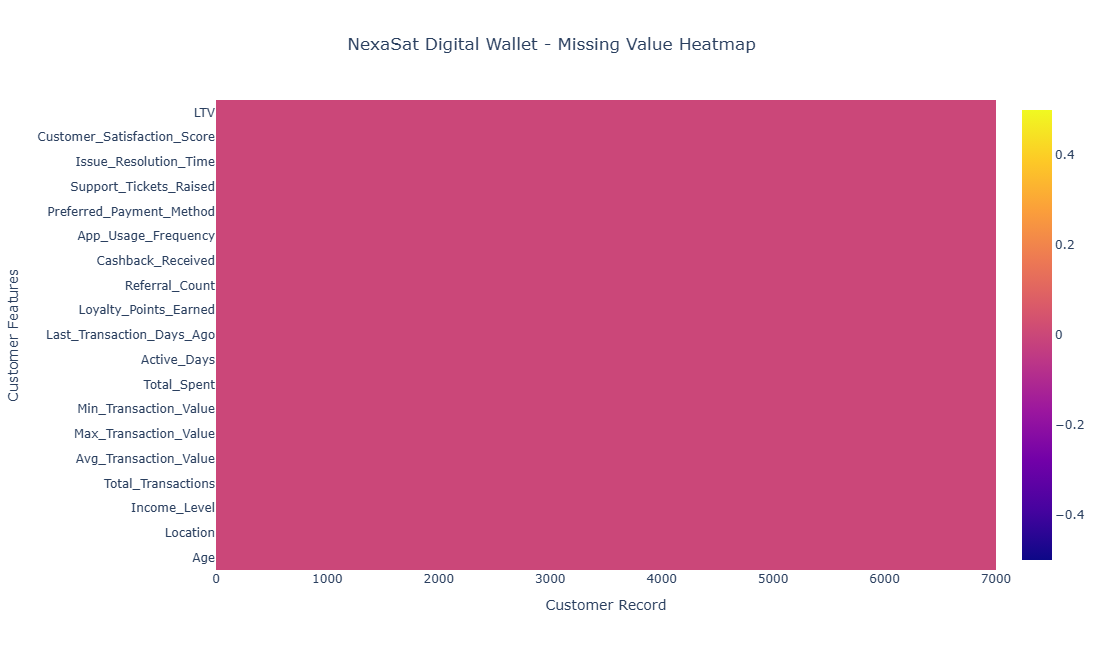

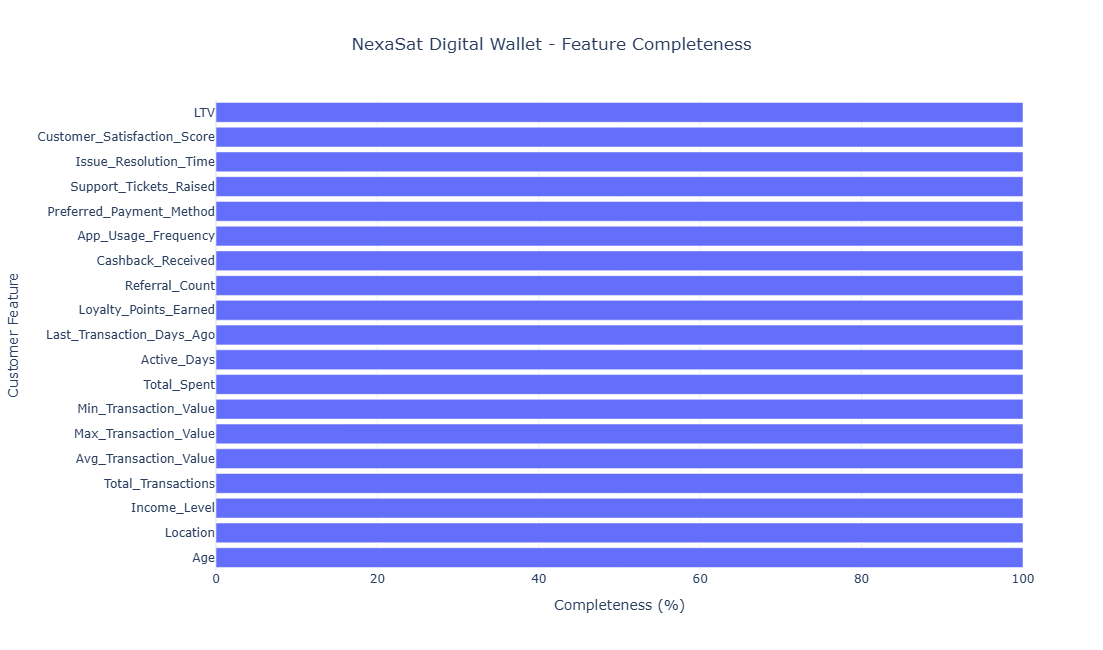

MISSING VALUE VISUALISATION COMPLETED

Features Analysed       : 19
Customer Records        : 7,000
Total Missing Values    : 0
Overall Completeness    : 100.0%
Features With Missing Data: 0

Overall Assessment:
The NexaSat Digital Wallet dataset contains no missing observations.


In [9]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED MISSING VALUE VISUALISATION PIPELINE
# =============================================================================
#
# Objective:
# -----------------------------------------------------------------------------
# Automatically assess and visualise missing values within the NexaSat
# Digital Wallet customer dataset using Plotly interactive visualisations.
#
# Visualisation is used alongside the numerical missing-value analysis to
# provide a clearer understanding of data completeness across customer
# attributes.
#
# The pipeline produces:
#
# 1. Missing Value Heatmap
#    - Shows the location of missing observations
#    - Helps identify patterns of missingness across customer records
#
# 2. Feature Completeness Bar Chart
#    - Shows the percentage of non-missing observations for each feature
#    - Helps identify variables requiring further investigation
#
#
# Workflow:
#
# NexaSat Digital Wallet Dataset
#             ↓
#      Detect Missing Values
#             ↓
#     Calculate Missingness
#             ↓
#    Calculate Completeness
#             ↓
#      Plot Missingness
#             ↓
#  Plot Feature Completeness
#             ↓
#       Assess Data Quality
#
# =============================================================================


def visualise_missing_values(
    dataframe: pd.DataFrame
):
    """
    Generate interactive Plotly visualisations of missing values within the
    NexaSat Digital Wallet customer dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        NexaSat Digital Wallet customer dataset.

    Returns
    -------
    None

    Displays
    --------
    1. Interactive missing-value heatmap.
    2. Interactive feature completeness bar chart.
    """


    # =========================================================================
    # STEP 1: VALIDATE INPUT DATASET
    # =========================================================================
    #
    # Confirm that the supplied object is a pandas DataFrame.
    #
    # This prevents unexpected errors if an incorrect object is supplied
    # to the visualisation function.
    #
    # =========================================================================

    if not isinstance(dataframe, pd.DataFrame):

        raise TypeError(
            "Input must be a pandas DataFrame."
        )


    # =========================================================================
    # STEP 2: CALCULATE MISSING VALUE COUNTS
    # =========================================================================
    #
    # Purpose:
    # Determine the number of missing observations within every feature.
    #
    # isnull():
    # Identifies missing observations.
    #
    # sum():
    # Counts the number of missing observations within each feature.
    #
    # =========================================================================

    missing_count = (
        dataframe
        .isnull()
        .sum()
    )


    # =========================================================================
    # STEP 3: CALCULATE MISSING VALUE PERCENTAGE
    # =========================================================================
    #
    # Purpose:
    # Calculate the percentage of missing observations for every feature.
    #
    # Formula:
    #
    # Missing Percentage =
    #
    # (Missing Values / Total Customer Records) × 100
    #
    # =========================================================================

    missing_percentage = (
        missing_count
        / len(dataframe)
        * 100
    ).round(2)


    # =========================================================================
    # STEP 4: CALCULATE FEATURE COMPLETENESS
    # =========================================================================
    #
    # Purpose:
    # Calculate the percentage of available, non-missing observations for
    # each NexaSat Digital Wallet feature.
    #
    # Formula:
    #
    # Completeness =
    #
    # 100 - Missing Percentage
    #
    # A value of 100% means that the feature contains no missing observations.
    #
    # =========================================================================

    completeness_percentage = (
        100 - missing_percentage
    ).round(2)


    # =========================================================================
    # STEP 5: CALCULATE OVERALL DATASET COMPLETENESS
    # =========================================================================
    #
    # Purpose:
    # Provide an overall assessment of the completeness of the dataset.
    #
    # =========================================================================

    total_missing = missing_count.sum()

    total_cells = (
        dataframe.shape[0]
        * dataframe.shape[1]
    )

    overall_completeness = (
        (total_cells - total_missing)
        / total_cells
        * 100
    ).round(2)


    # =========================================================================
    # STEP 6: DISPLAY DATA QUALITY SUMMARY
    # =========================================================================
    #
    # Provide a numerical summary before generating the interactive charts.
    #
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET")
    print("MISSING VALUE VISUALISATION")
    print("=" * 80)

    print(
        f"\nCustomer Records       : "
        f"{dataframe.shape[0]:,}"
    )

    print(
        f"Features Analysed      : "
        f"{dataframe.shape[1]:,}"
    )

    print(
        f"Total Missing Values   : "
        f"{total_missing:,}"
    )

    print(
        f"Overall Completeness   : "
        f"{overall_completeness}%"
    )


    # =========================================================================
    # STEP 7: CREATE MISSING VALUE HEATMAP
    # =========================================================================
    #
    # Purpose:
    # Display the location of missing and non-missing observations across
    # the NexaSat customer dataset.
    #
    # Each row represents a customer observation.
    #
    # Each column represents a dataset feature.
    #
    # The heatmap allows us to visually identify:
    #
    # - Individual missing observations
    # - Concentrated missingness
    # - Patterns across variables
    # - Potential systematic missingness
    #
    # A large dataset may contain many rows, therefore customer IDs are not
    # displayed on the y-axis.
    #
    # =========================================================================

    missing_matrix = dataframe.isnull().astype(int)

    missing_matrix.index = (
        range(1, len(dataframe) + 1)
    )


    fig_heatmap = go.Figure(
        data=go.Heatmap(
            z=missing_matrix.T.values,
            x=list(missing_matrix.index),
            y=list(missing_matrix.columns),
            hovertemplate=(
                "Customer Record: %{x}<br>"
                "Feature: %{y}<br>"
                "Missing: %{z}<extra></extra>"
            )
        )
    )


    fig_heatmap.update_layout(

        title={
            "text": (
                "NexaSat Digital Wallet - "
                "Missing Value Heatmap"
            ),
            "x": 0.5
        },

        xaxis_title="Customer Record",

        yaxis_title="Customer Features",

        height=650,

        template="plotly_white"
    )


    fig_heatmap.show()


    # =========================================================================
    # STEP 8: CREATE FEATURE COMPLETENESS DATAFRAME
    # =========================================================================
    #
    # Purpose:
    # Create a structured dataset for the feature completeness visualisation.
    #
    # Each feature is assigned:
    #
    # - Missing value count
    # - Missing percentage
    # - Completeness percentage
    #
    # =========================================================================

    completeness_df = pd.DataFrame({

        "Feature": dataframe.columns,

        "Missing_Values": missing_count.values,

        "Missing_Percentage": missing_percentage.values,

        "Completeness_Percentage":
            completeness_percentage.values

    })


    # =========================================================================
    # STEP 9: SORT FEATURES BY COMPLETENESS
    # =========================================================================
    #
    # Purpose:
    # Arrange features from least complete to most complete.
    #
    # This makes variables requiring attention immediately visible.
    #
    # =========================================================================

    completeness_df = (
        completeness_df
        .sort_values(
            by="Completeness_Percentage",
            ascending=True
        )
        .reset_index(drop=True)
    )


    # =========================================================================
    # STEP 10: CREATE FEATURE COMPLETENESS BAR CHART
    # =========================================================================
    #
    # Purpose:
    # Visually compare the completeness of all NexaSat Digital Wallet
    # variables.
    #
    # Interpretation:
    #
    # 100%:
    #     No missing observations.
    #
    # Below 100%:
    #     One or more observations are missing.
    #
    # The hover information also displays the exact number and percentage
    # of missing observations.
    #
    # =========================================================================

    fig_completeness = px.bar(

        completeness_df,

        x="Completeness_Percentage",

        y="Feature",

        orientation="h",

        hover_data={
            "Missing_Values": True,
            "Missing_Percentage": True,
            "Completeness_Percentage": True
        },

        labels={
            "Completeness_Percentage":
                "Completeness (%)",

            "Feature":
                "Customer Feature",

            "Missing_Values":
                "Missing Values",

            "Missing_Percentage":
                "Missing (%)"
        },

        title=(
            "NexaSat Digital Wallet - "
            "Feature Completeness"
        )
    )


    # =========================================================================
    # STEP 11: FORMAT FEATURE COMPLETENESS CHART
    # =========================================================================

    fig_completeness.update_layout(

        title={
            "x": 0.5
        },

        xaxis={
            "range": [0, 100],
            "title": "Completeness (%)"
        },

        yaxis_title="Customer Feature",

        height=650,

        template="plotly_white"
    )


    fig_completeness.show()


    # =========================================================================
    # STEP 12: IDENTIFY FEATURES WITH MISSING VALUES
    # =========================================================================
    #
    # Purpose:
    # Identify the specific variables that require further investigation.
    #
    # =========================================================================

    features_with_missing = (
        missing_count[
            missing_count > 0
        ]
        .index
        .tolist()
    )


    # =========================================================================
    # STEP 13: DISPLAY FINAL ASSESSMENT
    # =========================================================================

    print("=" * 80)
    print("MISSING VALUE VISUALISATION COMPLETED")
    print("=" * 80)

    print(
        f"\nFeatures Analysed       : "
        f"{dataframe.shape[1]}"
    )

    print(
        f"Customer Records        : "
        f"{dataframe.shape[0]:,}"
    )

    print(
        f"Total Missing Values    : "
        f"{total_missing:,}"
    )

    print(
        f"Overall Completeness    : "
        f"{overall_completeness}%"
    )

    print(
        f"Features With Missing Data: "
        f"{len(features_with_missing)}"
    )


    if features_with_missing:

        print(
            "\nFeatures Requiring Further Investigation:"
        )

        for feature in features_with_missing:

            print(
                f"  - {feature}"
            )

    else:

        print(
            "\nOverall Assessment:"
        )

        print(
            "The NexaSat Digital Wallet dataset "
            "contains no missing observations."
        )


# =============================================================================
# EXECUTE NEXASAT MISSING VALUE VISUALISATION PIPELINE
# =============================================================================
#
# Execute the interactive Plotly visualisation pipeline.
#
# The visualisations complement the numerical missing-value analysis and
# provide graphical evidence of data completeness before missing-value
# treatment.
#
# =============================================================================

visualise_missing_values(df)

# Handling Duplicated Variables

In [10]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED DUPLICATE CUSTOMER RECORD DETECTION AND REMOVAL PIPELINE
# =============================================================================
#
# Objective:
# -----------------------------------------------------------------------------
# This pipeline identifies and removes exact duplicate records from the
# NexaSat Digital Wallet customer dataset before Exploratory Data Analysis
# (EDA), feature engineering, and Customer Lifetime Value (LTV) modelling.
#
# Duplicate records occur when the same customer observation appears more
# than once with identical values across all variables.
#
# For example:
#
# Customer_ID | Age | Total_Transactions | Total_Spent | LTV
# -----------------------------------------------------------
# 10001       | 35  | 120                | 4500        | 850
# 10001       | 35  | 120                | 4500        | 850
#
# The second row is an exact duplicate of the first observation.
#
#
# Why duplicate detection is important for NexaSat:
# -----------------------------------------------------------------------------
# Duplicate records can cause:
#
# - Customer observations to be counted more than once
# - Transaction behaviour to be incorrectly represented
# - Customer-level statistics to become distorted
# - Feature distributions to become biased
# - Model training data to contain repeated observations
# - Certain customer segments to become over-represented
# - LTV model performance estimates to become unreliable
#
# Removing exact duplicates helps ensure that each unique observation is
# represented only once in the modelling dataset.
#
#
# IMPORTANT:
# -----------------------------------------------------------------------------
# This pipeline removes ONLY exact duplicate rows.
#
# It does NOT automatically remove:
#
# - Customers with the same Customer_ID but different information
# - Multiple legitimate records belonging to the same customer
# - Similar customer records
# - Transaction-level records
# - Data-entry errors that do not produce identical rows
#
# This distinction is important because the NexaSat dataset contains
# Customer_ID and customer behavioural variables.
#
# If the same Customer_ID appears multiple times with different values,
# additional investigation is required rather than automatically deleting
# those observations.
#
#
# Data Cleaning Workflow:
# -----------------------------------------------------------------------------
#
# Raw NexaSat Dataset
#          ↓
# Validate Input
#          ↓
# Record Original Dataset Size
#          ↓
# Detect Exact Duplicate Rows
#          ↓
# Calculate Duplicate Rate
#          ↓
# Remove Duplicate Rows
#          ↓
# Reset DataFrame Index
#          ↓
# Validate Dataset Size
#          ↓
# Return Clean Dataset
#
# =============================================================================


def remove_duplicate_records(
    dataframe: pd.DataFrame
) -> pd.DataFrame:

    """
    Detect and remove exact duplicate records from the NexaSat Digital
    Wallet customer dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        NexaSat Digital Wallet customer dataset containing customer
        characteristics, behavioural variables, and LTV.

    Returns
    -------
    pandas.DataFrame
        Dataset with exact duplicate records removed and the index reset.

    Notes
    -----
    Only exact duplicate rows are removed.

    Multiple observations associated with the same Customer_ID are not
    automatically removed because they may represent legitimate customer
    observations.
    """


    # =========================================================================
    # STEP 1: VALIDATE INPUT DATASET
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Confirm that the input provided to the function is a pandas DataFrame.
    #
    # The remainder of this function uses pandas-specific methods such as:
    #
    # - .duplicated()
    # - .drop_duplicates()
    # - .reset_index()
    # - .shape
    #
    # If the wrong object type is supplied, the function stops early and
    # provides a clear error message rather than producing an unclear error
    # later in the pipeline.
    #
    # =========================================================================

    if not isinstance(dataframe, pd.DataFrame):

        raise TypeError(
            "Input must be a pandas DataFrame."
        )


    # =========================================================================
    # STEP 2: RECORD ORIGINAL DATASET SIZE
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Store the number of observations before duplicate removal.
    #
    # This provides a baseline that can later be compared with the number of
    # observations remaining after cleaning.
    #
    # Example:
    #
    # Original dataset = 10,000 customer records
    # After duplicate removal = 9,950 records
    #
    # Therefore:
    #
    # Records removed = 50
    #
    # =========================================================================

    original_records = len(dataframe)


    # =========================================================================
    # STEP 3: DETECT EXACT DUPLICATE RECORDS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Identify observations that are exact duplicates of a previous row.
    #
    # pandas.DataFrame.duplicated() compares the values across the columns
    # of each row.
    #
    # By default:
    #
    # - The first occurrence is treated as the original record.
    # - Subsequent identical records are classified as duplicates.
    #
    # Example:
    #
    # Row 1 → Original
    # Row 2 → Duplicate of Row 1
    # Row 3 → Duplicate of Row 1
    #
    # duplicated() therefore identifies Row 2 and Row 3 as duplicates.
    #
    # sum() converts the True/False results into a total duplicate count.
    #
    # =========================================================================

    duplicate_count = (
        dataframe
        .duplicated()
        .sum()
    )


    # =========================================================================
    # STEP 4: CALCULATE DUPLICATE RECORD PERCENTAGE
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Calculate the percentage of the original dataset represented by
    # duplicate observations.
    #
    # Formula:
    #
    # Duplicate Rate (%) =
    #
    #       Duplicate Records
    #       ----------------- × 100
    #       Original Records
    #
    # The duplicate rate provides context for the raw duplicate count.
    #
    # For example:
    #
    # 100 duplicates in a dataset of 100,000 records = 0.10%
    #
    # 100 duplicates in a dataset of 1,000 records = 10.00%
    #
    # =========================================================================

    duplicate_percentage = (
        duplicate_count
        / original_records
        * 100
    ).round(2)


    # =========================================================================
    # STEP 5: DISPLAY DUPLICATE ANALYSIS RESULTS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Provide a clear summary of the duplicate-record assessment.
    #
    # This creates an audit trail showing the condition of the dataset before
    # duplicate removal.
    #
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET")
    print("DUPLICATE CUSTOMER RECORD ANALYSIS")
    print("=" * 80)

    print(
        f"\nOriginal Customer Records : "
        f"{original_records:,}"
    )

    print(
        f"Duplicate Records Detected: "
        f"{duplicate_count:,}"
    )

    print(
        f"Duplicate Record Rate     : "
        f"{duplicate_percentage}%"
    )


    # =========================================================================
    # STEP 6: REMOVE EXACT DUPLICATE RECORDS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Remove exact duplicate observations from the dataset.
    #
    # drop_duplicates():
    # ---------------------------------------------------------
    # Removes duplicate rows while retaining the first occurrence.
    #
    # keep="first":
    # ---------------------------------------------------------
    # Explicitly tells pandas to retain the first occurrence and remove
    # subsequent identical observations.
    #
    # reset_index(drop=True):
    # ---------------------------------------------------------
    # Rebuilds the DataFrame index after rows have been removed.
    #
    # drop=True prevents the old index from becoming an additional column.
    #
    # =========================================================================

    if duplicate_count > 0:

        dataframe = (
            dataframe
            .drop_duplicates(
                keep="first"
            )
            .reset_index(drop=True)
        )


        print(
            f"\nDuplicate Records Removed : "
            f"{duplicate_count:,}"
        )

    else:

        # ---------------------------------------------------------------------
        # If no duplicate records exist, no changes are made to the dataset.
        # ---------------------------------------------------------------------

        print(
            "\nNo exact duplicate customer records "
            "were detected."
        )

        print(
            "No records were removed."
        )


    # =========================================================================
    # STEP 7: CALCULATE RECORDS REMAINING
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Calculate the number of customer observations remaining after duplicate
    # treatment.
    #
    # This provides a direct validation of the cleaning operation.
    #
    # =========================================================================

    remaining_records = len(dataframe)


    # =========================================================================
    # STEP 8: CALCULATE TOTAL RECORDS REMOVED
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Calculate the difference between the original dataset size and the
    # cleaned dataset size.
    #
    # Formula:
    #
    # Records Removed =
    #
    # Original Records - Remaining Records
    #
    # This should normally equal the duplicate_count calculated earlier.
    #
    # =========================================================================

    records_removed = (
        original_records
        - remaining_records
    )


    # =========================================================================
    # STEP 9: DISPLAY CLEANING RESULTS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Provide a post-cleaning summary showing the effect of duplicate removal.
    #
    # =========================================================================

    print(
        f"Records Remaining         : "
        f"{remaining_records:,}"
    )

    print(
        f"Records Removed           : "
        f"{records_removed:,}"
    )


    # =========================================================================
    # STEP 10: DISPLAY UPDATED DATASET DIMENSIONS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Display the number of rows and columns remaining after duplicate
    # treatment.
    #
    # Shape is represented as:
    #
    # (Rows, Columns)
    #
    # Rows:
    #     Number of unique observations remaining.
    #
    # Columns:
    #     Number of customer attributes and the LTV target.
    #
    # =========================================================================

    print("\nUpdated NexaSat Dataset Shape:")
    print(dataframe.shape)


    # =========================================================================
    # STEP 11: RETURN CLEANED DATASET
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Return the cleaned DataFrame so it can be passed directly into the next
    # stage of the NexaSat data-preprocessing pipeline.
    #
    # The cleaned dataset can subsequently be used for:
    #
    # - Data type validation
    # - Outlier analysis
    # - Categorical encoding
    # - Feature engineering
    # - Feature selection
    # - LTV target analysis
    # - Train/test dataset preparation
    # - Machine learning model development
    #
    # =========================================================================

    return dataframe


# =============================================================================
# EXECUTE NEXASAT DUPLICATE RECORD REMOVAL PIPELINE
# =============================================================================
#
# Run the duplicate detection and removal function on the current NexaSat
# Digital Wallet dataset.
#
# The cleaned DataFrame replaces the previous version of "df".
#
# =============================================================================

df = remove_duplicate_records(df)


# =============================================================================
# NEXT STAGES OF THE NEXASAT DATA CLEANING AND PREPROCESSING PIPELINE
# =============================================================================
#
# After duplicate treatment, the NexaSat dataset progresses through:
#
# 1. Data Type Validation
#       ↓
# 2. Outlier Detection and Treatment
#       ↓
# 3. Categorical Variable Analysis
#       ↓
# 4. Categorical Encoding
#       ↓
# 5. Feature Engineering
#       ↓
# 6. Feature Selection
#       ↓
# 7. Data Leakage Assessment
#       ↓
# 8. Train/Test Data Preparation
#       ↓
# 9. LTV Model Development
#       ↓
# 10. Model Evaluation and Explainability
#
# =============================================================================

NEXASAT DIGITAL WALLET
DUPLICATE CUSTOMER RECORD ANALYSIS

Original Customer Records : 7,000
Duplicate Records Detected: 0
Duplicate Record Rate     : 0.0%

No exact duplicate customer records were detected.
No records were removed.
Records Remaining         : 7,000
Records Removed           : 0

Updated NexaSat Dataset Shape:
(7000, 19)


# Save Clean Data

In [11]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# SAVE CLEANED CUSTOMER DATASET
# =============================================================================
#
# Objective:
# -----------------------------------------------------------------------------
# Save the cleaned NexaSat Digital Wallet customer dataset to a CSV file
# after completing the initial data cleaning and quality-assurance stages.
#
# The cleaned dataset provides a reliable foundation for subsequent:
#
# - Exploratory Data Analysis (EDA)
# - Feature Engineering
# - Customer Lifetime Value (LTV) analysis
# - Feature Selection
# - Machine Learning Model Development
#
#
# Output File:
#     clean_data.csv
#
# The pandas-generated index is excluded because it is not a meaningful
# customer attribute and should not be used as a modelling feature.
#
# =============================================================================


# =========================================================================
# STEP 1: SPECIFY OUTPUT FILE
# =========================================================================
#
# Define the name of the cleaned NexaSat Digital Wallet dataset.
#
# =========================================================================

output_file = "clean_data.csv"


# =========================================================================
# STEP 2: EXPORT CLEANED DATASET
# =========================================================================
#
# Save the current DataFrame to CSV format.
#
# index=False:
# Prevents pandas from adding the DataFrame index as an additional column.
#
# =========================================================================

df.to_csv(
    output_file,
    index=False
)


# =========================================================================
# STEP 3: CONFIRM SUCCESSFUL EXPORT
# =========================================================================
#
# Display information confirming that the cleaned dataset has been saved.
#
# =========================================================================

print("=" * 80)
print("NEXASAT DIGITAL WALLET")
print("CLEANED DATASET SUCCESSFULLY SAVED")
print("=" * 80)

print(
    f"\nFile Name      : {output_file}"
)

print(
    f"Dataset Shape  : {df.shape}"
)

print(
    f"Rows           : {df.shape[0]:,}"
)

print(
    f"Columns        : {df.shape[1]:,}"
)

print(
    "Location       : Current Working Directory"
)


# =============================================================================
# NEXT NEXASAT ANALYTICS STAGES
# =============================================================================
#
# The "clean_data.csv" dataset can now be used as the foundation for:
#
# Cleaned Dataset
#        ↓
# Exploratory Data Analysis (EDA)
#        ↓
# Feature Engineering
#        ↓
# Feature Selection
#        ↓
# Train/Test Split
#        ↓
# LTV Model Development
#        ↓
# Model Evaluation
#        ↓
# Explainable AI / SHAP Analysis
#
# =============================================================================

NEXASAT DIGITAL WALLET
CLEANED DATASET SUCCESSFULLY SAVED

File Name      : clean_data.csv
Dataset Shape  : (7000, 19)
Rows           : 7,000
Columns        : 19
Location       : Current Working Directory


# Import Cleaned Dataset

In [12]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED CLEANED DATASET IMPORT PIPELINE
# =============================================================================
#
# Objective:
# -----------------------------------------------------------------------------
# Automatically locate and import the cleaned NexaSat Digital Wallet
# customer dataset (clean_data.csv) into a pandas DataFrame.
#
# This pipeline marks the transition from the Data Cleaning and Preprocessing
# stage to the Exploratory Data Analysis (EDA), Feature Engineering, and
# Customer Lifetime Value (LTV) Modelling stages.
#
#
# The imported dataset is expected to contain:
#
# - Customer demographic characteristics
# - Customer transaction behaviour
# - Customer engagement indicators
# - Customer service interactions
# - Customer satisfaction information
# - LTV target variable
#
#
# Automation Benefits:
# -----------------------------------------------------------------------------
# - Eliminates unnecessary hardcoded file paths
# - Improves notebook portability
# - Supports reproducible analytical workflows
# - Verifies that the cleaned dataset exists before loading
# - Confirms successful dataset import
# - Provides an initial structural validation
# - Creates a consistent input for downstream LTV analysis
#
#
# Workflow:
#
# clean_data.csv
#       ↓
# Verify File Exists
#       ↓
# Import Cleaned Dataset
#       ↓
# Validate Successful Import
#       ↓
# Check Dataset Dimensions
#       ↓
# Review Feature Names
#       ↓
# Preview Customer Records
#       ↓
# Inspect Data Types and Completeness
#       ↓
# Prepare for EDA and LTV Modelling
#
# =============================================================================


def load_clean_dataset(
    file_name="clean_data.csv"
) -> pd.DataFrame:

    """
    Automatically imports the cleaned NexaSat Digital Wallet dataset.

    Parameters
    ----------
    file_name : str, optional
        Name of the cleaned CSV dataset.
        Default = "clean_data.csv"

    Returns
    -------
    pandas.DataFrame
        Cleaned NexaSat Digital Wallet dataset ready for exploratory
        analysis, feature engineering, and LTV modelling.
    """


    # =========================================================================
    # STEP 1: VERIFY CLEANED DATASET EXISTS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Before attempting to import the dataset, verify that clean_data.csv
    # exists in the current working directory.
    #
    # This prevents a pandas FileNotFoundError and provides a clearer message
    # explaining that the expected NexaSat dataset could not be located.
    #
    # =========================================================================

    if not os.path.exists(file_name):

        raise FileNotFoundError(
            f"'{file_name}' was not found in the "
            "current working directory."
        )


    # =========================================================================
    # STEP 2: IMPORT CLEANED NEXASAT DATASET
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Load the cleaned CSV dataset into a pandas DataFrame.
    #
    # The DataFrame becomes the primary data object for the remaining
    # NexaSat Customer Lifetime Value analytics workflow.
    #
    # pandas provides the structure required for:
    #
    # - Exploratory Data Analysis
    # - Statistical analysis
    # - Data visualisation
    # - Feature engineering
    # - Feature transformation
    # - Feature selection
    # - Machine learning
    # - Model explainability
    #
    # =========================================================================

    df = pd.read_csv(file_name)


    # =========================================================================
    # STEP 3: CONFIRM SUCCESSFUL DATASET IMPORT
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Confirm that the cleaned NexaSat dataset has been successfully imported.
    #
    # Displaying the source file provides an audit trail and confirms that
    # the intended cleaned dataset is being used.
    #
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET")
    print("CLEANED DATASET LOADED SUCCESSFULLY")
    print("=" * 80)

    print(
        f"\nDataset Name:"
    )

    print(file_name)


    # =========================================================================
    # STEP 4: DISPLAY DATASET DIMENSIONS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Display the number of customer observations and variables contained
    # within the cleaned dataset.
    #
    # Dataset Shape:
    #
    # (Rows, Columns)
    #
    # Rows:
    #     Number of NexaSat customer observations.
    #
    # Columns:
    #     Number of customer attributes and the LTV target.
    #
    # This provides a baseline before beginning EDA and modelling.
    #
    # =========================================================================

    print("\nDataset Shape:")
    print(df.shape)

    print(
        f"Rows    : {df.shape[0]:,}"
    )

    print(
        f"Columns : {df.shape[1]:,}"
    )


    # =========================================================================
    # STEP 5: DISPLAY DATASET FEATURES
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Display all variables available in the cleaned NexaSat dataset.
    #
    # This allows the analyst to verify that:
    #
    # - Expected customer attributes are present
    # - Transaction variables are available
    # - Engagement variables are available
    # - Customer service variables are available
    # - LTV is present as the target variable
    # - Unwanted identifier or leakage variables have been removed
    #
    # =========================================================================

    print("\nNexaSat Dataset Columns:")
    print("=" * 80)

    for column_number, column in enumerate(
        df.columns,
        start=1
    ):

        print(
            f"{column_number:02d}. {column}"
        )


    # =========================================================================
    # STEP 6: PREVIEW CUSTOMER RECORDS
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Display the first five customer observations.
    #
    # This provides a quick visual validation that:
    #
    # - The dataset has been imported correctly
    # - Column names are correct
    # - Customer observations are available
    # - Numerical values are correctly formatted
    # - Categorical values are correctly represented
    # - The LTV target is present
    #
    # =========================================================================

    print("\nFirst Five NexaSat Customer Records:")

    display(
        df.head()
    )


    # =========================================================================
    # STEP 7: DISPLAY DATASET INFORMATION
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Generate a technical summary of the cleaned dataset.
    #
    # df.info() provides:
    #
    # - Number of observations
    # - Number of variables
    # - Column names
    # - Data types
    # - Non-null observations
    # - Memory usage
    #
    # This is particularly important before LTV modelling because machine
    # learning algorithms require correctly formatted predictor variables.
    #
    # =========================================================================

    print("\nNexaSat Dataset Information:")

    df.info()


    # =========================================================================
    # STEP 8: CHECK LTV TARGET VARIABLE
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Confirm that the Customer Lifetime Value (LTV) target variable exists
    # in the cleaned dataset.
    #
    # The LTV variable is the dependent variable that the machine learning
    # models will ultimately learn to predict.
    #
    # If LTV is missing from the dataset, the modelling pipeline should stop
    # because supervised LTV prediction cannot proceed without a target.
    #
    # =========================================================================

    if "LTV" not in df.columns:

        raise ValueError(
            "The 'LTV' target variable was not found "
            "in the cleaned NexaSat dataset."
        )

    print(
        "\nLTV Target Variable:"
    )

    print(
        "Confirmed - 'LTV' is available for "
        "Customer Lifetime Value modelling."
    )


    # =========================================================================
    # STEP 9: RETURN CLEANED DATASET
    # =========================================================================
    #
    # Purpose:
    # -------------------------------------------------------------------------
    # Return the imported NexaSat DataFrame.
    #
    # The returned dataset becomes the main input for the next analytical
    # stages of the project.
    #
    # =========================================================================

    return df


# =============================================================================
# EXECUTE NEXASAT CLEANED DATASET IMPORT PIPELINE
# =============================================================================
#
# Load the cleaned NexaSat Digital Wallet dataset.
#
# The resulting DataFrame (df) becomes the primary dataset for:
#
# - Exploratory Data Analysis (EDA)
# - Customer behaviour analysis
# - LTV distribution analysis
# - Feature engineering
# - Feature selection
# - Model development
# - Model evaluation
# - Explainable AI
#
# =============================================================================

df = load_clean_dataset()


# =============================================================================
# NEXASAT ANALYTICS PIPELINE TRANSITION
# =============================================================================
#
# Data Cleaning & Preprocessing
#             ↓
#       clean_data.csv
#             ↓
#    Load Cleaned Dataset
#             ↓
# Exploratory Data Analysis
#             ↓
# Customer Behaviour Analysis
#             ↓
# LTV Distribution Analysis
#             ↓
# Feature Engineering
#             ↓
# Feature Selection
#             ↓
# Train/Test Split
#             ↓
# LTV Model Development
#             ↓
# Model Evaluation
#             ↓
# Explainable AI (SHAP)
#
# =============================================================================

NEXASAT DIGITAL WALLET
CLEANED DATASET LOADED SUCCESSFULLY

Dataset Name:
clean_data.csv

Dataset Shape:
(7000, 19)
Rows    : 7,000
Columns : 19

NexaSat Dataset Columns:
01. Age
02. Location
03. Income_Level
04. Total_Transactions
05. Avg_Transaction_Value
06. Max_Transaction_Value
07. Min_Transaction_Value
08. Total_Spent
09. Active_Days
10. Last_Transaction_Days_Ago
11. Loyalty_Points_Earned
12. Referral_Count
13. Cashback_Received
14. App_Usage_Frequency
15. Preferred_Payment_Method
16. Support_Tickets_Raised
17. Issue_Resolution_Time
18. Customer_Satisfaction_Score
19. LTV

First Five NexaSat Customer Records:


,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,54,Urban,Low,192,16736.38402,60216.83451,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,67,Suburban,High,979,14536.73468,48350.10027,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,44,Urban,High,329,7061.37280,32521.15719,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,30,Rural,High,71,16426.87645,17827.89672,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,58,Urban,Middle,878,10800.09266,17497.63453,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05



NexaSat Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          7000 non-null   int64  
 1   Location                     7000 non-null   str    
 2   Income_Level                 7000 non-null   str    
 3   Total_Transactions           7000 non-null   int64  
 4   Avg_Transaction_Value        7000 non-null   float64
 5   Max_Transaction_Value        7000 non-null   float64
 6   Min_Transaction_Value        7000 non-null   float64
 7   Total_Spent                  7000 non-null   float64
 8   Active_Days                  7000 non-null   int64  
 9   Last_Transaction_Days_Ago    7000 non-null   int64  
 10  Loyalty_Points_Earned        7000 non-null   int64  
 11  Referral_Count               7000 non-null   int64  
 12  Cashback_Received            7000 non-null   float64
 13 

# Numerical Feature Engineering Pipeline

In [13]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED NUMERICAL FEATURE ENGINEERING PIPELINE
# =============================================================================
#
# Project:
# NexaSat Digital Wallet – AI-Driven Customer Lifetime Value (LTV) Prediction
#
# =============================================================================
# OBJECTIVE
# =============================================================================
#
# Feature engineering transforms existing raw customer attributes into
# additional variables that capture meaningful patterns in customer
# behaviour.
#
# For the NexaSat Digital Wallet project, the objective is to transform
# transactional, engagement, recency, and customer-support information into
# behavioural indicators that may provide additional predictive information
# for Customer Lifetime Value (LTV).
#
# Rather than creating a large number of arbitrary variables, this pipeline
# focuses on six high-priority features with a clear business interpretation:
#
# 1. Transaction_Value_Range
# 2. Spend_Per_Active_Day
# 3. Transactions_Per_Active_Day
# 4. Spend_Per_Transaction
# 5. Inactivity_Ratio
# 6. Support_Burden
#
#
# =============================================================================
# WHY FEATURE ENGINEERING IS IMPORTANT FOR NEXASAT
# =============================================================================
#
# Original variables describe individual aspects of customer behaviour.
#
# For example:
#
# Total_Spent
#     → Measures cumulative customer spending.
#
# Total_Transactions
#     → Measures the number of transactions.
#
# Active_Days
#     → Measures customer activity duration.
#
# Last_Transaction_Days_Ago
#     → Measures customer recency.
#
# Support_Tickets_Raised
#     → Measures customer support interaction.
#
# However, individual variables do not always capture the complete behavioural
# relationship between these measurements.
#
# Feature engineering combines existing variables to derive more meaningful
# behavioural indicators.
#
#
# Example:
#
# Customer A
# Total Spent = £10,000
# Active Days = 100
#
# Customer B
# Total Spent = £10,000
# Active Days = 500
#
# Both customers have identical Total_Spent.
#
# However:
#
# Customer A:
# £10,000 / 100 = £100 per active day
#
# Customer B:
# £10,000 / 500 = £20 per active day
#
# Therefore, Spend_Per_Active_Day provides additional behavioural information
# that Total_Spent alone cannot capture.
#
#
# =============================================================================
# FEATURE ENGINEERING WORKFLOW
# =============================================================================
#
#                     CLEAN NEXASAT DATASET
#                              │
#                              ↓
#                    Validate Source Variables
#                              │
#                              ↓
#                     Create Dataset Copy
#                              │
#                              ↓
#                    Create Safe Denominators
#                              │
#                              ↓
#              ┌───────────────┼────────────────┐
#              │               │                │
#              ↓               ↓                ↓
#        Transaction       Engagement       Customer
#          Behaviour        Behaviour       Experience
#              │               │                │
#              ↓               ↓                ↓
#       Value Range       Spend / Day      Support Burden
#                         Transactions /
#                         Active Day
#                         Spend /
#                         Transaction
#                         Inactivity Ratio
#                              │
#                              ↓
#                  Validate Engineered Features
#                              │
#                              ↓
#                    Generate Feature Report
#                              │
#                              ↓
#                   FEATURE-READY DATASET
#                              │
#                              ↓
#                 Encoding / Feature Selection
#                              │
#                              ↓
#                    LTV MODEL DEVELOPMENT
#
#
# IMPORTANT:
# The target variable LTV is NOT used in any feature-engineering calculation.
#
# This is essential because using LTV to construct predictor variables would
# introduce target leakage and could produce unrealistically strong model
# performance.
#
# =============================================================================


def engineer_nexasat_features(
    dataframe: pd.DataFrame
) -> pd.DataFrame:

    """
    Automatically engineers numerical behavioural features for the
    NexaSat Digital Wallet Customer Lifetime Value prediction project.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Cleaned NexaSat customer dataset.

    Returns
    -------
    pandas.DataFrame
        Dataset containing the original variables plus six engineered
        numerical behavioural features.

    Notes
    -----
    The function does not modify the original dataframe because a copy is
    created before feature engineering begins.

    The function also validates required source variables and checks for
    missing or infinite values after feature creation.
    """


    # =========================================================================
    # STEP 1: CREATE A COPY OF THE INPUT DATASET
    # =========================================================================
    #
    # Purpose:
    # Create an independent copy of the cleaned dataset.
    #
    # Why?
    #
    # Feature engineering modifies the dataframe by adding new columns.
    # Working on a copy prevents accidental modification of the original
    # cleaned dataset.
    #
    # This is particularly important in a machine learning project because
    # the original cleaned dataset may later be required for:
    #
    # • Exploratory Data Analysis
    # • Alternative feature engineering approaches
    # • Model comparison
    # • Data quality auditing
    #
    # =========================================================================

    data = dataframe.copy()


    # =========================================================================
    # STEP 2: DEFINE REQUIRED SOURCE VARIABLES
    # =========================================================================
    #
    # Purpose:
    # Identify all original variables required to calculate the six
    # engineered features.
    #
    # These variables represent four major areas of NexaSat customer
    # behaviour:
    #
    # Transaction behaviour
    #     Max_Transaction_Value
    #     Min_Transaction_Value
    #     Total_Spent
    #     Total_Transactions
    #
    # Engagement
    #     Active_Days
    #
    # Recency
    #     Last_Transaction_Days_Ago
    #
    # Customer experience
    #     Support_Tickets_Raised
    #     Issue_Resolution_Time
    #
    # =========================================================================

    required_features = [

        "Max_Transaction_Value",

        "Min_Transaction_Value",

        "Total_Spent",

        "Active_Days",

        "Total_Transactions",

        "Last_Transaction_Days_Ago",

        "Support_Tickets_Raised",

        "Issue_Resolution_Time"

    ]


    # =========================================================================
    # STEP 3: VALIDATE REQUIRED SOURCE VARIABLES
    # =========================================================================
    #
    # Purpose:
    # Confirm that all required source variables exist before calculations
    # are performed.
    #
    # Without this validation, the pipeline could fail with a generic
    # KeyError, making it difficult to identify which variable is missing.
    #
    # The explicit validation creates a more robust and reusable pipeline.
    #
    # This is particularly useful if the NexaSat dataset is later updated
    # or the pipeline is applied to another version of the dataset.
    #
    # =========================================================================

    missing_features = [

        column

        for column in required_features

        if column not in data.columns

    ]


    if missing_features:

        raise ValueError(

            "Feature engineering cannot continue. "
            f"Missing required columns: {missing_features}"

        )


    # =========================================================================
    # STEP 4: DEFINE ENGINEERED FEATURE LIST
    # =========================================================================
    #
    # Purpose:
    # Maintain a central list containing all features generated by this
    # pipeline.
    #
    # Keeping the list in one location makes it easier to:
    #
    # • Validate the output
    # • Generate summary reports
    # • Inspect distributions
    # • Perform feature selection later
    #
    # =========================================================================

    engineered_features = [

        "Transaction_Value_Range",

        "Spend_Per_Active_Day",

        "Transactions_Per_Active_Day",

        "Spend_Per_Transaction",

        "Inactivity_Ratio",

        "Support_Burden"

    ]


    # =========================================================================
    # STEP 5: REMOVE PREVIOUSLY GENERATED FEATURES
    # =========================================================================
    #
    # Purpose:
    # Make the function safe to execute multiple times.
    #
    # If the function is run twice on the same dataframe, the engineered
    # columns may already exist.
    #
    # Removing them first ensures that the features are recalculated from
    # the original source variables rather than creating duplicated or
    # inconsistent features.
    #
    # =========================================================================

    existing_engineered_features = [

        column

        for column in engineered_features

        if column in data.columns

    ]


    if existing_engineered_features:

        data = data.drop(

            columns=existing_engineered_features

        )


    # =========================================================================
    # STEP 6: CREATE SAFE DENOMINATORS
    # =========================================================================
    #
    # Purpose:
    # Protect ratio calculations from division-by-zero errors.
    #
    # Two variables are used as denominators:
    #
    # Active_Days
    # Total_Transactions
    #
    # If either contains zero, ordinary division could produce:
    #
    # inf
    # -inf
    # or an invalid result.
    #
    # Therefore, zero values are temporarily converted to NaN.
    #
    # These NaN values can then be handled during the appropriate missing-value
    # treatment stage.
    #
    # This approach is preferable to artificially adding 1 to every
    # denominator because adding 1 changes the mathematical meaning of the
    # ratio.
    #
    # =========================================================================

    active_days_denominator = (

        data["Active_Days"]

        .replace(0, np.nan)

    )


    transaction_denominator = (

        data["Total_Transactions"]

        .replace(0, np.nan)

    )


    # =========================================================================
    # STEP 7: CREATE TRANSACTION VALUE RANGE
    # =========================================================================
    #
    # Formula:
    #
    # Transaction_Value_Range =
    #
    # Max_Transaction_Value
    # -
    # Min_Transaction_Value
    #
    #
    # Business Interpretation:
    # -------------------------------------------------------------------------
    #
    # This feature measures the variability in the monetary size of a
    # customer's transactions.
    #
    # A high Transaction_Value_Range indicates that the customer's transaction
    # sizes vary substantially.
    #
    # A low value indicates that the customer's transactions tend to have
    # relatively similar monetary values.
    #
    # This provides additional information beyond simply knowing the average
    # transaction value.
    #
    # =========================================================================

    data["Transaction_Value_Range"] = (

        data["Max_Transaction_Value"]

        - data["Min_Transaction_Value"]

    )


    # =========================================================================
    # STEP 8: CREATE SPEND PER ACTIVE DAY
    # =========================================================================
    #
    # Formula:
    #
    # Spend_Per_Active_Day =
    #
    # Total_Spent
    # ------------
    # Active_Days
    #
    #
    # Business Interpretation:
    # -------------------------------------------------------------------------
    #
    # Measures the customer's spending intensity relative to their active
    # usage period.
    #
    # This normalises total spending by customer activity duration.
    #
    # A high value indicates that a customer generates substantial spending
    # during each active day.
    #
    # A low value indicates lower spending intensity.
    #
    # Potential relevance to LTV:
    # Customers with higher spending intensity may generate greater economic
    # value for the digital-wallet platform.
    #
    # =========================================================================

    data["Spend_Per_Active_Day"] = (

        data["Total_Spent"]

        / active_days_denominator

    )


    # =========================================================================
    # STEP 9: CREATE TRANSACTIONS PER ACTIVE DAY
    # =========================================================================
    #
    # Formula:
    #
    # Transactions_Per_Active_Day =
    #
    # Total_Transactions
    # ------------------
    # Active_Days
    #
    #
    # Business Interpretation:
    # -------------------------------------------------------------------------
    #
    # Measures transaction frequency relative to the customer's active
    # engagement period.
    #
    # This helps distinguish:
    #
    # • Highly engaged customers who transact frequently
    #
    # from
    #
    # • Customers who transact relatively infrequently.
    #
    # For a digital-wallet business, transaction frequency can be an important
    # behavioural indicator of customer engagement and potential future value.
    #
    # =========================================================================

    data["Transactions_Per_Active_Day"] = (

        data["Total_Transactions"]

        / active_days_denominator

    )


    # =========================================================================
    # STEP 10: CREATE SPEND PER TRANSACTION
    # =========================================================================
    #
    # Formula:
    #
    # Spend_Per_Transaction =
    #
    # Total_Spent
    # ------------
    # Total_Transactions
    #
    #
    # Business Interpretation:
    # -------------------------------------------------------------------------
    #
    # Measures the average monetary value generated by each transaction.
    #
    # This helps distinguish between different transaction strategies.
    #
    # Example:
    #
    # Customer A:
    #     Many transactions with relatively small values.
    #
    # Customer B:
    #     Fewer transactions with substantially larger values.
    #
    # Total spending alone may not fully distinguish these behaviours.
    #
    # Spend_Per_Transaction provides additional transaction-economic context.
    #
    # IMPORTANT:
    #
    # The original dataset already contains:
    #
    # Avg_Transaction_Value
    #
    # Therefore, this engineered feature should later be assessed for
    # redundancy using correlation and feature importance analysis.
    #
    # =========================================================================

    data["Spend_Per_Transaction"] = (

        data["Total_Spent"]

        / transaction_denominator

    )


    # =========================================================================
    # STEP 11: CREATE INACTIVITY RATIO
    # =========================================================================
    #
    # Formula:
    #
    # Inactivity_Ratio =
    #
    # Last_Transaction_Days_Ago
    # -------------------------
    # Active_Days
    #
    #
    # Business Interpretation:
    # -------------------------------------------------------------------------
    #
    # Last_Transaction_Days_Ago measures the number of days since the
    # customer's most recent transaction.
    #
    # However, customers can have different engagement histories.
    #
    # Normalising inactivity relative to Active_Days creates a relative
    # measure of inactivity.
    #
    # Higher values indicate greater inactivity relative to the customer's
    # active usage period.
    #
    # Lower values indicate stronger recent engagement.
    #
    # This feature may therefore help identify customers whose engagement
    # could be weakening.
    #
    # =========================================================================

    data["Inactivity_Ratio"] = (

        data["Last_Transaction_Days_Ago"]

        / active_days_denominator

    )


    # =========================================================================
    # STEP 12: CREATE SUPPORT BURDEN
    # =========================================================================
    #
    # Formula:
    #
    # Support_Burden =
    #
    # Support_Tickets_Raised
    #          ×
    # Issue_Resolution_Time
    #
    #
    # Business Interpretation:
    # -------------------------------------------------------------------------
    #
    # Customer support activity can provide information about customer
    # experience.
    #
    # A customer raising many support tickets and experiencing long
    # resolution times may have a different relationship with the platform
    # from a customer who rarely requires support.
    #
    # The interaction between ticket volume and resolution time provides a
    # simple measure of cumulative support burden.
    #
    # Potential interpretation:
    #
    # Higher Support_Burden
    #     → Greater customer-service burden
    #
    # Lower Support_Burden
    #     → Lower support requirements
    #
    # This feature can subsequently be tested for its relationship with LTV.
    #
    # =========================================================================

    data["Support_Burden"] = (

        data["Support_Tickets_Raised"]

        * data["Issue_Resolution_Time"]

    )


    # =========================================================================
    # STEP 13: HANDLE INFINITE VALUES
    # =========================================================================
    #
    # Purpose:
    # Replace positive and negative infinity values with NaN.
    #
    # Infinite values can occur when mathematical operations produce invalid
    # results.
    #
    # Converting them to NaN ensures that they can be identified and handled
    # consistently during subsequent preprocessing.
    #
    # =========================================================================

    data[engineered_features] = (

        data[engineered_features]

        .replace(

            [np.inf, -np.inf],

            np.nan

        )

    )


    # =========================================================================
    # STEP 14: VALIDATE MISSING VALUES
    # =========================================================================
    #
    # Purpose:
    # Determine whether feature engineering introduced missing values.
    #
    # Missing values can occur, for example, when:
    #
    # Active_Days = 0
    #
    # or
    #
    # Total_Transactions = 0
    #
    # because zero denominators were deliberately converted to NaN.
    #
    # This validation ensures that the issue is visible before the dataset
    # proceeds to modelling.
    #
    # =========================================================================

    missing_counts = (

        data[engineered_features]

        .isnull()

        .sum()

    )


    # =========================================================================
    # STEP 15: VALIDATE INFINITE VALUES
    # =========================================================================
    #
    # Purpose:
    # Confirm that no infinite numerical values remain in the engineered
    # features.
    #
    # =========================================================================

    infinite_counts = (

        np.isinf(

            data[engineered_features]

            .select_dtypes(include=np.number)

        )

        .sum()

    )


    total_missing = missing_counts.sum()

    total_infinite = infinite_counts.sum()


    # =========================================================================
    # STEP 16: CREATE FEATURE QUALITY REPORT
    # =========================================================================
    #
    # Purpose:
    # Create a structured audit table for the six engineered variables.
    #
    # The report allows us to verify:
    #
    # • Data type
    # • Missing observations
    # • Missing percentage
    # • Number of unique values
    #
    # This makes the feature-engineering stage auditable and reproducible.
    #
    # =========================================================================

    feature_summary = pd.DataFrame({

        "Feature": engineered_features,

        "Data_Type": [

            str(data[feature].dtype)

            for feature in engineered_features

        ],

        "Missing_Count": [

            missing_counts[feature]

            for feature in engineered_features

        ],

        "Missing_Percentage": [

            round(

                missing_counts[feature]

                / len(data)

                * 100,

                2

            )

            for feature in engineered_features

        ],

        "Unique_Count": [

            data[feature].nunique()

            for feature in engineered_features

        ]

    })


    # =========================================================================
    # STEP 17: DISPLAY FEATURE ENGINEERING REPORT
    # =========================================================================
    #
    # Purpose:
    # Provide an automated summary confirming that the feature-engineering
    # stage has completed successfully.
    #
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET")
    print("NUMERICAL FEATURE ENGINEERING REPORT")
    print("=" * 80)

    print(
        f"\nOriginal Dataset Shape   : "
        f"{dataframe.shape}"
    )

    print(
        f"Engineered Dataset Shape : "
        f"{data.shape}"
    )

    print(
        f"New Features Created    : "
        f"{len(engineered_features)}"
    )

    print(
        f"Missing Values Created   : "
        f"{total_missing}"
    )

    print(
        f"Infinite Values Found    : "
        f"{total_infinite}"
    )


    # Display detailed quality report.

    print("\nEngineered Feature Quality Report:")

    display(feature_summary)


    # =========================================================================
    # STEP 18: DISPLAY SUMMARY STATISTICS
    # =========================================================================
    #
    # Purpose:
    # Examine the statistical distributions of the engineered variables.
    #
    # The summary includes:
    #
    # • Count
    # • Mean
    # • Standard deviation
    # • Minimum
    # • 25th percentile
    # • Median
    # • 75th percentile
    # • Maximum
    #
    # This is particularly useful for identifying variables with extreme
    # ranges or potential outliers before modelling.
    #
    # =========================================================================

    print("\nEngineered Feature Summary Statistics:")

    display(

        data[engineered_features]

        .describe()

        .T

    )


    # =========================================================================
    # STEP 19: DISPLAY ENGINEERED FEATURE PREVIEW
    # =========================================================================
    #
    # Purpose:
    # Display a sample of the newly created variables.
    #
    # This provides a quick manual validation that the calculations have
    # produced sensible results.
    #
    # =========================================================================

    print("\nEngineered Feature Preview:")

    display(

        data[engineered_features]

        .head()

    )


    # =========================================================================
    # STEP 20: FINAL DATASET VALIDATION
    # =========================================================================
    #
    # Confirm that all six expected engineered features exist in the output.
    #
    # This acts as a final quality-control checkpoint before the dataset
    # moves to subsequent preprocessing stages.
    #
    # =========================================================================

    missing_engineered_columns = [

        feature

        for feature in engineered_features

        if feature not in data.columns

    ]


    if missing_engineered_columns:

        raise RuntimeError(

            "Feature engineering failed. "
            f"Missing engineered columns: "
            f"{missing_engineered_columns}"

        )


    print("\nFeature Engineering Validation: PASSED")


    # =========================================================================
    # STEP 21: RETURN ENGINEERED DATASET
    # =========================================================================
    #
    # The returned dataframe contains:
    #
    # • Original numerical variables
    # • Original categorical variables
    # • LTV target variable
    # • Six newly engineered behavioural variables
    #
    # The dataset can now proceed to:
    #
    #     Feature Distribution Analysis
    #                ↓
    #     Correlation Analysis
    #                ↓
    #     Multicollinearity Assessment
    #                ↓
    #     Categorical Encoding
    #                ↓
    #     Feature Selection
    #                ↓
    #     Train/Test Split
    #                ↓
    #     LTV Model Development
    #
    # =========================================================================

    return data


# =============================================================================
# EXECUTE AUTOMATED NEXASAT FEATURE ENGINEERING PIPELINE
# =============================================================================
#
# The pipeline automatically performs:
#
# 1. Dataset copying
# 2. Required-variable validation
# 3. Existing engineered-feature detection
# 4. Safe denominator creation
# 5. Six behavioural feature calculations
# 6. Infinite-value handling
# 7. Missing-value validation
# 8. Feature quality reporting
# 9. Summary-statistics generation
# 10. Output validation
#
# The resulting dataframe is stored in df and becomes the input for the
# subsequent NexaSat preprocessing stages.
#
# =============================================================================

df = engineer_nexasat_features(df)

NEXASAT DIGITAL WALLET
NUMERICAL FEATURE ENGINEERING REPORT

Original Dataset Shape   : (7000, 19)
Engineered Dataset Shape : (7000, 25)
New Features Created    : 6
Missing Values Created   : 0
Infinite Values Found    : 0

Engineered Feature Quality Report:


,Feature,Data_Type,Missing_Count,Missing_Percentage,Unique_Count
0,Transaction_Value_Range,float64,0,0.0,7000
1,Spend_Per_Active_Day,float64,0,0.0,7000
2,Transactions_Per_Active_Day,float64,0,0.0,6639
3,Spend_Per_Transaction,float64,0,0.0,7000
4,Inactivity_Ratio,float64,0,0.0,6295
5,Support_Burden,float64,0,0.0,6664



Engineered Feature Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Transaction_Value_Range,7000.0,27178.046832,20677.120470,26.929645,10371.728477,22507.104403,40369.630940,9.426355e+04
Spend_Per_Active_Day,7000.0,87030.901302,400680.457487,6.872218,8085.181430,23803.691983,55195.104648,1.655609e+07
Transactions_Per_Active_Day,7000.0,9.027255,37.715227,0.002793,1.405718,2.755357,5.548746,9.790000e+02
Spend_Per_Transaction,7000.0,9946.831482,5780.880831,10.185827,4907.466790,9841.172644,14955.048805,1.999645e+04
Inactivity_Ratio,7000.0,3.297073,14.439300,0.002762,0.517341,1.000000,1.995312,3.640000e+02
Support_Burden,7000.0,368.011250,325.779877,0.000000,94.229924,275.819155,571.050462,1.437389e+03



Engineered Feature Preview:


,Transaction_Value_Range,Spend_Per_Active_Day,Transactions_Per_Active_Day,Spend_Per_Transaction,Inactivity_Ratio,Support_Burden
0,53691.019649,22952.755229,1.371429,16736.384021,1.492857,184.705769
1,46163.358025,62146.127729,4.275109,14536.734678,1.048035,1026.679110
2,29777.750382,31824.543164,4.506849,7061.372799,0.287671,498.361365
3,13467.111726,3900.696415,0.237458,16426.876451,0.953177,132.181143
4,12964.762010,40180.005742,3.720339,10800.092659,1.394068,371.425007



Feature Engineering Validation: PASSED


# Remove Variables used in Feature Engineering

In [14]:
# =============================================================================
# AUTOMATED SOURCE FEATURE REMOVAL AFTER FEATURE ENGINEERING
# =============================================================================
#
# Objective:
# Remove the original source variables after their information has been
# transformed into engineered behavioural features for the NexaSat Digital
# Wallet Customer Lifetime Value (CLV) model.
#
# =============================================================================
# WHY REMOVE THE SOURCE VARIABLES?
# =============================================================================
#
# During feature engineering, several raw transaction and behavioural
# variables are combined to create more informative customer-level metrics.
#
# For example:
#
#     Total_Spent / Active_Days
#              ↓
#     Spend_Per_Active_Day
#
# Once the engineered feature has been created, retaining both the original
# variables and the derived feature can introduce substantial redundancy.
#
# Removing the selected source variables helps to:
#
# 1. Reduce redundant information
# 2. Simplify the model feature space
# 3. Improve feature interpretability
# 4. Reduce potential multicollinearity for linear models
# 5. Create a more behaviourally meaningful CLV feature set
# 6. Make downstream model interpretation easier
# 7. Prevent multiple highly related representations of the same behaviour
#
# IMPORTANT:
# -------------------------------------------------------------------------
# This should NOT be described as target leakage prevention.
#
# None of these source variables directly contains LTV.
#
# Target leakage is prevented by ensuring that LTV is not included among
# the predictor variables when X and y are created.
#
#     X = Predictor Features
#     y = LTV
#
# =============================================================================
#
# SOURCE FEATURE → ENGINEERED FEATURE MAPPING
# =============================================================================
#
# 1. Max_Transaction_Value
#    +
#    Min_Transaction_Value
#    ↓
#    Transaction_Value_Range
#
#    Why remove the sources?
#    -----------------------
#    The range captures the customer's transaction-value variability:
#
#       Maximum transaction - Minimum transaction
#
#    For CLV modelling, the range provides a direct measure of how widely
#    transaction values vary rather than keeping two separate absolute
#    transaction boundaries.
#
#
# 2. Total_Spent
#    +
#    Active_Days
#    ↓
#    Spend_Per_Active_Day
#
#    Why remove the sources?
#    -----------------------
#    Total_Spent measures overall spending, while Active_Days measures the
#    duration of customer activity.
#
#    Their ratio provides a more comparable measure of spending intensity:
#
#       Total_Spent / Active_Days
#
#    This helps distinguish a customer who spends heavily because they have
#    been active for a long period from a customer who generates high spending
#    intensity over a shorter active period.
#
#
# 3. Total_Transactions
#    +
#    Active_Days
#    ↓
#    Transactions_Per_Active_Day
#
#    Why remove the sources?
#    -----------------------
#    The engineered feature measures transaction frequency relative to
#    customer activity:
#
#       Total_Transactions / Active_Days
#
#    This provides a stronger behavioural indicator of engagement than the
#    raw transaction count alone.
#
#
# 4. Total_Spent
#    +
#    Total_Transactions
#    ↓
#    Spend_Per_Transaction
#
#    Why remove the sources?
#    -----------------------
#    This feature measures the customer's average monetary value per
#    transaction:
#
#       Total_Spent / Total_Transactions
#
#    It provides a direct measure of transaction economics and helps
#    distinguish high-value customers from customers who simply transact
#    frequently.
#
#
# 5. Last_Transaction_Days_Ago
#    +
#    Active_Days
#    ↓
#    Inactivity_Ratio
#
#    Why remove the sources?
#    -----------------------
#    The engineered feature combines transaction recency with customer
#    activity to create a relative inactivity measure.
#
#    This is particularly useful for CLV because recency is an important
#    indicator of whether a customer is likely to remain commercially active.
#
#
# 6. Support_Tickets_Raised
#    +
#    Issue_Resolution_Time
#    ↓
#    Support_Burden
#
#    Why remove the sources?
#    -----------------------
#    Support_Burden combines customer service contact frequency with the
#    time required to resolve those issues.
#
#    This creates a broader measure of customer-service friction:
#
#       Support Tickets × Resolution Time
#
#    A higher value may indicate greater service burden and potentially
#    poorer customer experience, which can be relevant to future customer
#    value.
#
# =============================================================================
#
# FINAL FEATURE DESIGN
# =============================================================================
#
# The objective is therefore to replace selected raw behavioural measures
# with more interpretable CLV-oriented features:
#
# Raw Transaction Data
#          ↓
# Behavioural Feature Engineering
#          ↓
# More Meaningful CLV Metrics
#          ↓
# Remove Redundant Source Variables
#          ↓
# Final CLV Modelling Dataset
#
# =============================================================================


def remove_engineered_source_features(
    dataframe: pd.DataFrame
) -> pd.DataFrame:

    """
    Removes selected source variables after their information has been
    incorporated into engineered NexaSat CLV features.

    The function preserves the engineered features and the LTV target.
    """

    # =========================================================================
    # STEP 1: CREATE A COPY
    # =========================================================================
    #
    # Work on a copy so that the original feature-engineered dataframe remains
    # available for auditing, comparison and reproducibility.
    #
    data = dataframe.copy()


    # =========================================================================
    # STEP 2: DEFINE ENGINEERED FEATURES
    # =========================================================================
    #
    # These features represent the higher-level behavioural measures that will
    # be retained for CLV modelling.
    #
    engineered_features = [
        "Transaction_Value_Range",
        "Spend_Per_Active_Day",
        "Transactions_Per_Active_Day",
        "Spend_Per_Transaction",
        "Inactivity_Ratio",
        "Support_Burden"
    ]


    # =========================================================================
    # STEP 3: DEFINE SOURCE FEATURES
    # =========================================================================
    #
    # These are the original variables used to construct the engineered
    # features.
    #
    # They are removed after feature engineering because their information has
    # already been incorporated into the engineered behavioural measures.
    #
    source_features = [
        "Max_Transaction_Value",
        "Min_Transaction_Value",
        "Total_Spent",
        "Active_Days",
        "Total_Transactions",
        "Last_Transaction_Days_Ago",
        "Support_Tickets_Raised",
        "Issue_Resolution_Time"
    ]


    # =========================================================================
    # STEP 4: VALIDATE ENGINEERED FEATURES
    # =========================================================================
    #
    # Before deleting anything, confirm that all engineered features exist.
    #
    # This is an important safety check:
    #
    # If feature engineering failed, the original source variables should
    # NOT be removed because their information would otherwise be lost.
    #
    missing_engineered_features = [
        feature
        for feature in engineered_features
        if feature not in data.columns
    ]


    if missing_engineered_features:

        raise ValueError(
            "Feature engineering validation failed. "
            f"Missing engineered features: {missing_engineered_features}"
        )


    # =========================================================================
    # STEP 5: RECORD ORIGINAL DATASET SIZE
    # =========================================================================
    #
    # Store the original dimensions so we can demonstrate the impact of
    # removing the redundant source variables.
    #
    original_shape = data.shape


    # =========================================================================
    # STEP 6: IDENTIFY AVAILABLE SOURCE FEATURES
    # =========================================================================
    #
    # Only remove source variables that are currently present.
    #
    # This makes the function safe to execute even if some variables have
    # already been removed during an earlier preprocessing step.
    #
    existing_source_features = [
        feature
        for feature in source_features
        if feature in data.columns
    ]


    # =========================================================================
    # STEP 7: REMOVE SOURCE FEATURES
    # =========================================================================
    #
    # Remove the original variables now that their information has been
    # represented through the engineered CLV features.
    #
    if existing_source_features:

        data.drop(
            columns=existing_source_features,
            inplace=True
        )


    # =========================================================================
    # STEP 8: VERIFY ENGINEERED FEATURES
    # =========================================================================
    #
    # Confirm that the six engineered CLV features remain in the dataset.
    #
    retained_engineered_features = [
        feature
        for feature in engineered_features
        if feature in data.columns
    ]


    # =========================================================================
    # STEP 9: PROTECT THE LTV TARGET
    # =========================================================================
    #
    # LTV is the dependent/target variable for the NexaSat CLV prediction
    # problem.
    #
    # It must remain in the dataframe at this stage.
    #
    # Later, it will be separated from the predictors:
    #
    #     X = df.drop(columns=["LTV"])
    #     y = df["LTV"]
    #
    if "LTV" not in data.columns:

        raise ValueError(
            "LTV target variable is missing. "
            "The target must be retained for CLV modelling."
        )


    # =========================================================================
    # STEP 10: VALIDATE SOURCE FEATURE REMOVAL
    # =========================================================================
    #
    # Confirm that none of the selected source variables remain.
    #
    remaining_source_features = [
        feature
        for feature in source_features
        if feature in data.columns
    ]


    if remaining_source_features:

        raise ValueError(
            "Source feature removal was incomplete: "
            f"{remaining_source_features}"
        )


    # =========================================================================
    # STEP 11: CALCULATE FINAL DATASET SIZE
    # =========================================================================

    final_shape = data.shape


    # =========================================================================
    # STEP 12: DISPLAY PIPELINE SUMMARY
    # =========================================================================

    print("=" * 80)
    print("NEXASAT DIGITAL WALLET - SOURCE FEATURE REMOVAL")
    print("=" * 80)

    print("\nPurpose:")
    print(
        "Remove redundant source variables after CLV feature engineering "
        "while retaining the engineered behavioural features."
    )

    print("\nOriginal Dataset Shape:")
    print(f"Rows    : {original_shape[0]}")
    print(f"Columns : {original_shape[1]}")

    print("\nSource Features Removed:")

    for feature in existing_source_features:
        print(f" ✓ {feature}")

    print("\nEngineered Features Retained:")

    for feature in retained_engineered_features:
        print(f" ✓ {feature}")

    print("\nTarget Variable:")
    print(" ✓ LTV")

    print("\nFinal Dataset Shape:")
    print(f"Rows    : {final_shape[0]}")
    print(f"Columns : {final_shape[1]}")

    print("\nValidation:")
    print(" ✓ Engineered features retained")
    print(" ✓ Source variables removed")
    print(" ✓ LTV target retained")
    print(" ✓ Dataset ready for categorical encoding and modelling")


    # =========================================================================
    # STEP 13: RETURN FINAL DATASET
    # =========================================================================

    return data


# =============================================================================
# EXECUTE AUTOMATED PIPELINE
# =============================================================================

df = remove_engineered_source_features(df)

NEXASAT DIGITAL WALLET - SOURCE FEATURE REMOVAL

Purpose:
Remove redundant source variables after CLV feature engineering while retaining the engineered behavioural features.

Original Dataset Shape:
Rows    : 7000
Columns : 25

Source Features Removed:
 ✓ Max_Transaction_Value
 ✓ Min_Transaction_Value
 ✓ Total_Spent
 ✓ Active_Days
 ✓ Total_Transactions
 ✓ Last_Transaction_Days_Ago
 ✓ Support_Tickets_Raised
 ✓ Issue_Resolution_Time

Engineered Features Retained:
 ✓ Transaction_Value_Range
 ✓ Spend_Per_Active_Day
 ✓ Transactions_Per_Active_Day
 ✓ Spend_Per_Transaction
 ✓ Inactivity_Ratio
 ✓ Support_Burden

Target Variable:
 ✓ LTV

Final Dataset Shape:
Rows    : 7000
Columns : 17

Validation:
 ✓ Engineered features retained
 ✓ Source variables removed
 ✓ LTV target retained
 ✓ Dataset ready for categorical encoding and modelling


# Save Final Data After Feature Engineering for EDA 

In [18]:
# =============================================================================
# SAVE FINAL FEATURE-ENGINEERED NEXASAT CLV DATASET
# =============================================================================
#
# Objective:
# Save the final NexaSat Digital Wallet dataset after:
#
# • Data cleaning
# • Duplicate removal
# • Feature engineering
# • Source-feature removal
#
# The resulting dataset contains the engineered CLV behavioural features
# together with the remaining customer attributes and the LTV target.
#
# Output File:
#     final_data.csv
#
# This file will be used for:
#
# • Exploratory Data Analysis (EDA)
# • Feature selection
# • Categorical encoding
# • Train/test splitting
# • CLV model development
# • Model evaluation
# • Explainable AI (SHAP)
#
# =============================================================================


# =========================================================================
# STEP 1: DEFINE OUTPUT FILE
# =========================================================================
#
# Specify the name of the final feature-engineered dataset.
#
output_file = "final_data.csv"


# =========================================================================
# STEP 2: SAVE DATASET
# =========================================================================
#
# Save the dataframe as a CSV file.
#
# index=False prevents pandas from creating an additional index column
# in the exported dataset.
#
df.to_csv(
    output_file,
    index=False
)


# =========================================================================
# STEP 3: CONFIRM SUCCESSFUL EXPORT
# =========================================================================
#
# Display a summary confirming that the final dataset has been saved.
#
print("=" * 80)
print("FINAL NEXASAT CLV DATASET SAVED SUCCESSFULLY")
print("=" * 80)

print(f"File Name     : {output_file}")
print(f"Dataset Shape : {df.shape}")
print("Index Saved   : No")
print("Status        : Ready for EDA and CLV modelling")

FINAL NEXASAT CLV DATASET SAVED SUCCESSFULLY
File Name     : final_data.csv
Dataset Shape : (7000, 17)
Index Saved   : No
Status        : Ready for EDA and CLV modelling


# Import the Final Datset

In [20]:
# =============================================================================
# AUTOMATED FINAL NEXASAT CLV DATASET IMPORT PIPELINE
# =============================================================================
#
# Objective:
# Automatically locate and import the final feature-engineered NexaSat
# Digital Wallet dataset saved as "final_data.csv".
#
# This dataset represents the output of the data cleaning and feature
# engineering stages and will be used for:
#
# • Exploratory Data Analysis (EDA)
# • Feature selection
# • Categorical encoding
# • Train/test splitting
# • CLV model development
# • Model evaluation
# • Explainable AI (SHAP)
#
# Workflow:
#
# final_data.csv
#       ↓
# Verify File Exists
#       ↓
# Import Dataset
#       ↓
# Validate Dataset
#       ↓
# Display Structure
#       ↓
# Return Final Dataset
#
# =============================================================================


def load_final_dataset(
    file_name="final_data.csv"
) -> pd.DataFrame:

    """
    Automatically loads the final NexaSat CLV dataset.

    Parameters
    ----------
    file_name : str, optional
        Name of the final feature-engineered CSV dataset.

    Returns
    -------
    pandas.DataFrame
        Final NexaSat dataset ready for EDA and modelling.
    """

    # =========================================================================
    # STEP 1: VERIFY FILE EXISTS
    # =========================================================================
    #
    # Check whether final_data.csv is available in the current working
    # directory before attempting to import it.
    #
    if not os.path.exists(file_name):

        raise FileNotFoundError(
            f"'{file_name}' was not found in the current working directory."
        )


    # =========================================================================
    # STEP 2: IMPORT FINAL DATASET
    # =========================================================================
    #
    # Load the CSV file into a pandas DataFrame.
    #
    data = pd.read_csv(file_name)


    # =========================================================================
    # STEP 3: DISPLAY IMPORT CONFIRMATION
    # =========================================================================

    print("=" * 80)
    print("FINAL NEXASAT CLV DATASET LOADED SUCCESSFULLY")
    print("=" * 80)

    print(f"\nDataset File:")
    print(file_name)


    # =========================================================================
    # STEP 4: DISPLAY DATASET DIMENSIONS
    # =========================================================================
    #
    # Confirm the number of customer observations and variables imported.
    #
    print("\nDataset Shape:")
    print(f"Rows    : {data.shape[0]}")
    print(f"Columns : {data.shape[1]}")


    # =========================================================================
    # STEP 5: DISPLAY FEATURE NAMES
    # =========================================================================
    #
    # Display all variables to confirm that the engineered CLV features
    # are present.
    #
    print("\nDataset Columns:")
    print("-" * 80)

    for number, column in enumerate(
        data.columns,
        start=1
    ):
        print(f"{number:02d}. {column}")


    # =========================================================================
    # STEP 6: VERIFY LTV TARGET
    # =========================================================================
    #
    # LTV must be present because it is the target variable for the
    # Customer Lifetime Value prediction model.
    #
    if "LTV" not in data.columns:

        raise ValueError(
            "LTV target variable was not found in final_data.csv."
        )

    print("\nTarget Variable:")
    print("✓ LTV")


    # =========================================================================
    # STEP 7: VERIFY ENGINEERED FEATURES
    # =========================================================================
    #
    # Confirm that the six engineered NexaSat behavioural features are
    # available in the final dataset.
    #
    engineered_features = [
        "Transaction_Value_Range",
        "Spend_Per_Active_Day",
        "Transactions_Per_Active_Day",
        "Spend_Per_Transaction",
        "Inactivity_Ratio",
        "Support_Burden"
    ]

    missing_features = [
        feature
        for feature in engineered_features
        if feature not in data.columns
    ]

    if missing_features:

        raise ValueError(
            "The following engineered features are missing: "
            f"{missing_features}"
        )

    print("\nEngineered CLV Features:")
    for feature in engineered_features:
        print(f"✓ {feature}")


    # =========================================================================
    # STEP 8: DISPLAY DATA PREVIEW
    # =========================================================================
    #
    # Display the first five observations for a quick visual validation.
    #
    print("\nFirst Five Records:")
    display(data.head())


    # =========================================================================
    # STEP 9: DISPLAY DATASET INFORMATION
    # =========================================================================
    #
    # Check data types and non-null observations before beginning EDA.
    #
    print("\nDataset Information:")
    data.info()


    # =========================================================================
    # STEP 10: RETURN FINAL DATASET
    # =========================================================================

    return data


# =============================================================================
# EXECUTE FINAL DATASET IMPORT
# =============================================================================

df = load_final_dataset()

FINAL NEXASAT CLV DATASET LOADED SUCCESSFULLY

Dataset File:
final_data.csv

Dataset Shape:
Rows    : 7000
Columns : 17

Dataset Columns:
--------------------------------------------------------------------------------
01. Age
02. Location
03. Income_Level
04. Avg_Transaction_Value
05. Loyalty_Points_Earned
06. Referral_Count
07. Cashback_Received
08. App_Usage_Frequency
09. Preferred_Payment_Method
10. Customer_Satisfaction_Score
11. LTV
12. Transaction_Value_Range
13. Spend_Per_Active_Day
14. Transactions_Per_Active_Day
15. Spend_Per_Transaction
16. Inactivity_Ratio
17. Support_Burden

Target Variable:
✓ LTV

Engineered CLV Features:
✓ Transaction_Value_Range
✓ Spend_Per_Active_Day
✓ Transactions_Per_Active_Day
✓ Spend_Per_Transaction
✓ Inactivity_Ratio
✓ Support_Burden

First Five Records:


,Age,Location,Income_Level,Avg_Transaction_Value,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Customer_Satisfaction_Score,LTV,Transaction_Value_Range,Spend_Per_Active_Day,Transactions_Per_Active_Day,Spend_Per_Transaction,Inactivity_Ratio,Support_Burden
0,54,Urban,Low,16736.38402,2114,25,2224.012140,Monthly,Debit Card,1,3.279546e+05,53691.019649,22952.755229,1.371429,16736.384021,1.492857,184.705769
1,67,Suburban,High,14536.73468,2960,20,4026.823518,Monthly,UPI,8,1.437053e+06,46163.358025,62146.127729,4.275109,14536.734678,1.048035,1026.679110
2,44,Urban,High,7061.37280,3170,0,1441.011395,Monthly,Debit Card,4,2.419387e+05,29777.750382,31824.543164,4.506849,7061.372799,0.287671,498.361365
3,30,Rural,High,16426.87645,4756,35,4365.855580,Weekly,Wallet Balance,1,1.284599e+05,13467.111726,3900.696415,0.237458,16426.876451,0.953177,132.181143
4,58,Urban,Middle,10800.09266,1992,18,4161.523827,Daily,UPI,5,9.569514e+05,12964.762010,40180.005742,3.720339,10800.092659,1.394068,371.425007



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          7000 non-null   int64  
 1   Location                     7000 non-null   str    
 2   Income_Level                 7000 non-null   str    
 3   Avg_Transaction_Value        7000 non-null   float64
 4   Loyalty_Points_Earned        7000 non-null   int64  
 5   Referral_Count               7000 non-null   int64  
 6   Cashback_Received            7000 non-null   float64
 7   App_Usage_Frequency          7000 non-null   str    
 8   Preferred_Payment_Method     7000 non-null   str    
 9   Customer_Satisfaction_Score  7000 non-null   int64  
 10  LTV                          7000 non-null   float64
 11  Transaction_Value_Range      7000 non-null   float64
 12  Spend_Per_Active_Day         7000 non-null   float64
 13  Transac

# Encoding Categorical Features

In [23]:
# =============================================================================
# NEXASAT DIGITAL WALLET
# AUTOMATED CATEGORICAL FEATURE ENCODING AND EXPORT PIPELINE
# =============================================================================
#
# Project:
# NexaSat Digital Wallet – AI-Driven Customer Lifetime Value (LTV) Prediction
#
# Input Dataset:
#     final_data.csv
#
# Output Dataset:
#     preprocessed_CLV.csv
#
# =============================================================================
# OBJECTIVE
# =============================================================================
#
# This pipeline prepares the final NexaSat Digital Wallet dataset for
# machine-learning-based Customer Lifetime Value (CLV/LTV) prediction.
#
# The dataset has already passed through:
#
#     • Missing-value assessment
#     • Duplicate-record treatment
#     • Feature engineering
#     • Removal of source variables used to construct engineered features
#
# Therefore, this pipeline focuses specifically on:
#
#     1. Loading the final feature-engineered dataset
#     2. Validating the dataset structure
#     3. Identifying categorical variables
#     4. Applying appropriate categorical encoding
#     5. Preserving numerical variables
#     6. Preserving the LTV target
#     7. Validating the transformed dataset
#     8. Saving the preprocessed dataset
#
#
# =============================================================================
# CATEGORICAL VARIABLES
# =============================================================================
#
# The NexaSat dataset contains four categorical variables:
#
#     Location
#     Income_Level
#     App_Usage_Frequency
#     Preferred_Payment_Method
#
#
# These variables are divided according to whether their categories have a
# meaningful natural ordering.
#
#
# =============================================================================
# ORDINAL VARIABLES
# =============================================================================
#
# Income_Level
#
#     Low < Middle < High
#
# The categories represent increasing income levels.
#
#
# App_Usage_Frequency
#
#     Monthly < Weekly < Daily
#
# The categories represent increasing frequency of digital-wallet usage.
#
# Because both variables have an inherent order, Ordinal Encoding is used.
#
#
# =============================================================================
# NOMINAL VARIABLES
# =============================================================================
#
# Location
#
#     Urban
#     Suburban
#     Rural
#
# There is no mathematical ranking between these geographical categories.
#
#
# Preferred_Payment_Method
#
#     Debit Card
#     UPI
#     Wallet Balance
#     Credit Card
#
# There is also no natural ranking between payment methods.
#
# Therefore, One-Hot Encoding is used.
#
#
# =============================================================================
# TARGET VARIABLE
# =============================================================================
#
# LTV
#
# LTV represents the customer's Lifetime Value.
#
# It is a continuous numerical variable and therefore:
#
#     LTV → No categorical encoding
#
# The target is preserved as a numerical variable for regression modelling.
#
#
# =============================================================================
# ENCODING STRATEGY
# =============================================================================
#
# Feature                       Method
# ---------------------------------------------------------------------------
# Income_Level                  Ordinal Encoding
# App_Usage_Frequency           Ordinal Encoding
# Location                      One-Hot Encoding
# Preferred_Payment_Method      One-Hot Encoding
# Numerical Features            Passed through unchanged
# LTV                           Passed through unchanged
#
#
# =============================================================================
# COMPLETE PIPELINE
# =============================================================================
#
# final_data.csv
#       ↓
# Load Dataset
#       ↓
# Validate Required Variables
#       ↓
# Identify Categorical Features
#       ↓
# Separate Ordinal and Nominal Features
#       ↓
# Handle Potential Missing Categories
#       ↓
# Ordinal Encoding
#       ↓
# One-Hot Encoding
#       ↓
# Preserve Numerical Features
#       ↓
# Preserve LTV Target
#       ↓
# Validate Numerical Dataset
#       ↓
# Validate Engineered Features
#       ↓
# Save as preprocessed_CLV.csv
#       ↓
# Machine Learning Modelling
#
# =============================================================================


def load_final_dataset(
    file_name="final_data.csv"
) -> pd.DataFrame:

    """
    Load the final feature-engineered NexaSat dataset.

    Parameters
    ----------
    file_name : str
        Name of the final feature-engineered CSV file.

    Returns
    -------
    pandas.DataFrame
        Loaded NexaSat dataset.
    """

    # =========================================================================
    # STEP 1: VERIFY THAT THE INPUT DATASET EXISTS
    # =========================================================================
    #
    # Before attempting to read the CSV file, confirm that the file exists.
    #
    # This prevents the pipeline from failing unexpectedly and provides a
    # clear explanation if the dataset is missing.
    #
    # =========================================================================

    if not os.path.exists(file_name):

        raise FileNotFoundError(
            f"'{file_name}' was not found in the current working directory."
        )


    # =========================================================================
    # STEP 2: LOAD THE FINAL FEATURE-ENGINEERED DATASET
    # =========================================================================
    #
    # The final_data.csv file represents the output of the previous
    # preprocessing and feature-engineering stages.
    #
    # It should contain:
    #
    #     • Retained numerical customer variables
    #     • Engineered behavioural variables
    #     • Remaining categorical variables
    #     • LTV target
    #
    # =========================================================================

    data = pd.read_csv(file_name)


    # =========================================================================
    # STEP 3: DISPLAY INPUT DATASET INFORMATION
    # =========================================================================
    #
    # Displaying the dataset dimensions and preview provides an immediate
    # confirmation that the correct file has been loaded.
    #
    # =========================================================================

    print("=" * 80)
    print("NEXASAT FINAL DATASET LOADED")
    print("=" * 80)

    print(f"\nInput File    : {file_name}")
    print(f"Dataset Shape : {data.shape}")

    print("\nDataset Preview:")
    display(data.head())


    return data


# =============================================================================
# CATEGORICAL FEATURE ENCODING FUNCTION
# =============================================================================


def encode_categorical_features(
    df: pd.DataFrame
) -> pd.DataFrame:

    """
    Encode categorical variables in the final NexaSat dataset.

    Ordinal variables:
        - Income_Level
        - App_Usage_Frequency

    Nominal variables:
        - Location
        - Preferred_Payment_Method

    Numerical variables and the LTV target are preserved.

    Parameters
    ----------
    df : pandas.DataFrame
        Final NexaSat feature-engineered dataset.

    Returns
    -------
    pandas.DataFrame
        Numerical dataset ready for machine learning.
    """


    # =========================================================================
    # STEP 1: CREATE A COPY OF THE DATASET
    # =========================================================================
    #
    # A copy is created so that the original final_data.csv representation is
    # not modified.
    #
    # This is important because the original dataset may still be required for:
    #
    #     • EDA
    #     • Business interpretation
    #     • Visualisation
    #     • Data-quality checks
    #     • Reproducibility
    #
    # =========================================================================

    data = df.copy()


    # =========================================================================
    # STEP 2: DEFINE CATEGORICAL FEATURES
    # =========================================================================
    #
    # These are the four categorical variables identified in the NexaSat
    # dataset.
    #
    # =========================================================================

    categorical_features = [

        "Location",

        "Income_Level",

        "App_Usage_Frequency",

        "Preferred_Payment_Method"

    ]


    # =========================================================================
    # STEP 3: VALIDATE CATEGORICAL FEATURES
    # =========================================================================
    #
    # Check that all expected categorical variables are present.
    #
    # This protects the pipeline against:
    #
    #     • Incorrect column names
    #     • Accidental deletion
    #     • Changes to the dataset structure
    #
    # =========================================================================

    missing_features = [

        column

        for column in categorical_features

        if column not in data.columns

    ]


    if missing_features:

        raise ValueError(
            "The following categorical features are missing: "
            f"{missing_features}"
        )


    # =========================================================================
    # STEP 4: VALIDATE LTV TARGET
    # =========================================================================
    #
    # LTV is the dependent variable in the NexaSat Customer Lifetime Value
    # prediction problem.
    #
    # The target must be retained throughout preprocessing because it will
    # later be separated from the predictor variables during model training.
    #
    # =========================================================================

    if "LTV" not in data.columns:

        raise ValueError(
            "The 'LTV' target variable is missing from final_data.csv."
        )


    # =========================================================================
    # STEP 5: DEFINE ORDINAL FEATURES
    # =========================================================================
    #
    # Ordinal features contain categories with meaningful natural ordering.
    #
    # Income_Level:
    #
    #     Low → Middle → High
    #
    #
    # App_Usage_Frequency:
    #
    #     Monthly → Weekly → Daily
    #
    # Ordinal encoding preserves these relationships.
    #
    # =========================================================================

    ordinal_features = [

        "Income_Level",

        "App_Usage_Frequency"

    ]


    # =========================================================================
    # STEP 6: DEFINE NOMINAL FEATURES
    # =========================================================================
    #
    # Nominal features contain categories without a meaningful numerical
    # ordering.
    #
    # One-Hot Encoding prevents the model from incorrectly interpreting one
    # category as being greater or smaller than another.
    #
    # =========================================================================

    nominal_features = [

        "Location",

        "Preferred_Payment_Method"

    ]


    # =========================================================================
    # STEP 7: DISPLAY ENCODING STRATEGY
    # =========================================================================

    print("\n" + "=" * 80)
    print("NEXASAT CATEGORICAL ENCODING STRATEGY")
    print("=" * 80)

    print("\nOrdinal Encoding:")
    print("  • Income_Level        → Low < Middle < High")
    print("  • App_Usage_Frequency → Monthly < Weekly < Daily")

    print("\nOne-Hot Encoding:")
    print("  • Location")
    print("  • Preferred_Payment_Method")

    print("\nNumerical Variables:")
    print("  • Passed through unchanged")

    print("\nTarget:")
    print("  • LTV → Preserved as numerical target")


    # =========================================================================
    # STEP 8: CREATE ORDINAL ENCODING PIPELINE
    # =========================================================================
    #
    # The ordinal pipeline contains two stages:
    #
    #     Missing Value Imputation
    #              ↓
    #     Ordinal Encoding
    #
    # Although the current dataset has already undergone missing-value
    # assessment, the imputer makes this pipeline more robust to future data.
    #
    # The explicit category ordering is important because it ensures that
    # the numerical representation reflects the business meaning.
    #
    # =========================================================================

    ordinal_pipeline = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="most_frequent"
                )

            ),

            (
                "ordinal_encoder",

                OrdinalEncoder(

                    categories=[

                        [
                            "Low",
                            "Middle",
                            "High"
                        ],

                        [
                            "Monthly",
                            "Weekly",
                            "Daily"
                        ]

                    ],

                    handle_unknown="use_encoded_value",

                    unknown_value=-1

                )

            )

        ]

    )


    # =========================================================================
    # STEP 9: CREATE NOMINAL / ONE-HOT ENCODING PIPELINE
    # =========================================================================
    #
    # The nominal pipeline converts unordered categorical variables into
    # binary indicator variables.
    #
    # Example:
    #
    # Location
    #
    #     Urban
    #     Suburban
    #     Rural
    #
    # can be represented using binary indicator variables.
    #
    #
    # drop="first":
    #
    # One category is omitted as the reference category. This reduces
    # redundant dummy variables and is particularly useful for linear
    # regression models.
    #
    #
    # handle_unknown="ignore":
    #
    # Allows the pipeline to process future data containing a category that
    # was not present when the encoder was fitted.
    #
    # =========================================================================

    nominal_pipeline = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="most_frequent"
                )

            ),

            (
                "one_hot_encoder",

                OneHotEncoder(

                    drop="first",

                    sparse_output=False,

                    handle_unknown="ignore"

                )

            )

        ]

    )


    # =========================================================================
    # STEP 10: COMBINE ENCODING STRATEGIES
    # =========================================================================
    #
    # ColumnTransformer allows different transformations to be applied to
    # different groups of variables.
    #
    # Ordinal variables:
    #
    #     Income_Level
    #     App_Usage_Frequency
    #
    # receive ordinal encoding.
    #
    #
    # Nominal variables:
    #
    #     Location
    #     Preferred_Payment_Method
    #
    # receive one-hot encoding.
    #
    #
    # Numerical variables:
    #
    #     remainder="passthrough"
    #
    # means they are retained without modification.
    #
    # This is important because the numerical engineered NexaSat features have
    # already been created during the feature-engineering stage.
    #
    # =========================================================================

    preprocessor = ColumnTransformer(

        transformers=[

            (
                "ordinal",

                ordinal_pipeline,

                ordinal_features

            ),

            (
                "nominal",

                nominal_pipeline,

                nominal_features

            )

        ],

        remainder="passthrough"

    )


    # =========================================================================
    # STEP 11: APPLY THE TRANSFORMATIONS
    # =========================================================================
    #
    # Fit the preprocessing transformer and apply it to the complete dataset.
    #
    # The resulting matrix contains:
    #
    #     • Ordinal encoded variables
    #     • One-Hot encoded variables
    #     • Existing numerical variables
    #     • Engineered numerical variables
    #     • LTV
    #
    # =========================================================================

    encoded_array = preprocessor.fit_transform(data)


    # =========================================================================
    # STEP 12: GENERATE ONE-HOT FEATURE NAMES
    # =========================================================================
    #
    # One-Hot Encoding creates new columns.
    #
    # We automatically retrieve their names so that the final dataset remains
    # interpretable.
    #
    # These names will also be important later for:
    #
    #     • Feature importance
    #     • SHAP explanations
    #     • Model coefficients
    #     • Feature selection
    #
    # =========================================================================

    onehot_columns = (

        preprocessor
        .named_transformers_["nominal"]
        .named_steps["one_hot_encoder"]
        .get_feature_names_out(nominal_features)

    )


    # =========================================================================
    # STEP 13: IDENTIFY NUMERICAL FEATURES
    # =========================================================================
    #
    # All variables not processed by the categorical pipelines are passed
    # through unchanged.
    #
    # This includes the engineered behavioural features:
    #
    #     • Transaction_Value_Range
    #     • Spend_Per_Active_Day
    #     • Transactions_Per_Active_Day
    #     • Spend_Per_Transaction
    #     • Inactivity_Ratio
    #     • Support_Burden
    #
    # It also includes LTV.
    #
    # =========================================================================

    numerical_features = [

        column

        for column in data.columns

        if column not in (
            ordinal_features
            + nominal_features
        )

    ]


    # =========================================================================
    # STEP 14: CONSTRUCT FINAL FEATURE NAMES
    # =========================================================================
    #
    # The transformed dataset is arranged as:
    #
    #     Ordinal Features
    #             +
    #     One-Hot Features
    #             +
    #     Numerical Features
    #
    # =========================================================================

    final_columns = (

        ordinal_features

        + list(onehot_columns)

        + numerical_features

    )


    # =========================================================================
    # STEP 15: CONVERT TRANSFORMED MATRIX BACK TO DATAFRAME
    # =========================================================================
    #
    # Convert the numerical matrix into a pandas DataFrame.
    #
    # Meaningful feature names are retained for subsequent modelling and
    # explainability.
    #
    # =========================================================================

    encoded_df = pd.DataFrame(

        encoded_array,

        columns=final_columns,

        index=data.index

    )


    # =========================================================================
    # STEP 16: VALIDATE NUMERICAL FEATURES
    # =========================================================================
    #
    # The objective of categorical encoding is to produce a fully numerical
    # modelling dataset.
    #
    # Check whether any non-numerical variables remain.
    #
    # =========================================================================

    non_numeric_columns = (

        encoded_df
        .select_dtypes(exclude=["number"])
        .columns
        .tolist()

    )


    print("\n" + "=" * 80)
    print("ENCODING VALIDATION")
    print("=" * 80)

    print(f"\nOriginal Dataset Shape : {data.shape}")
    print(f"Encoded Dataset Shape  : {encoded_df.shape}")

    if non_numeric_columns:

        print("\nWARNING: Non-numerical columns remain:")
        print(non_numeric_columns)

    else:

        print("\n✓ All features are numerical.")


    # =========================================================================
    # STEP 17: VALIDATE LTV TARGET
    # =========================================================================
    #
    # LTV must remain present because it is the target variable for the
    # Customer Lifetime Value prediction models.
    #
    # =========================================================================

    if "LTV" not in encoded_df.columns:

        raise ValueError(
            "LTV was not retained after categorical encoding."
        )


    if not pd.api.types.is_numeric_dtype(
        encoded_df["LTV"]
    ):

        raise TypeError(
            "LTV must remain a numerical variable."
        )


    print("✓ LTV target retained successfully.")


    # =========================================================================
    # STEP 18: VALIDATE ENGINEERED FEATURES
    # =========================================================================
    #
    # The six engineered behavioural variables were created during the
    # feature-engineering stage.
    #
    # They are numerical predictors and therefore should pass through the
    # categorical encoding stage unchanged.
    #
    # =========================================================================

    engineered_features = [

        "Transaction_Value_Range",

        "Spend_Per_Active_Day",

        "Transactions_Per_Active_Day",

        "Spend_Per_Transaction",

        "Inactivity_Ratio",

        "Support_Burden"

    ]


    missing_engineered_features = [

        feature

        for feature in engineered_features

        if feature not in encoded_df.columns

    ]


    if missing_engineered_features:

        print(
            "\nWARNING: The following engineered features "
            "are missing:"
        )

        for feature in missing_engineered_features:

            print(f"  ✗ {feature}")

    else:

        print("\n✓ All six engineered features retained successfully.")


    # =========================================================================
    # STEP 19: CHECK FOR MISSING VALUES AFTER ENCODING
    # =========================================================================
    #
    # Encoding should not introduce unexpected missing values.
    #
    # This validation confirms that the final modelling dataset is complete.
    #
    # =========================================================================

    total_missing = encoded_df.isnull().sum().sum()


    print("\nPost-Encoding Missing Values:")

    print(
        f"Total Missing Values : {total_missing}"
    )


    if total_missing == 0:

        print("✓ No missing values detected.")

    else:

        print(
            "WARNING: Missing values remain in the encoded dataset."
        )


    # =========================================================================
    # STEP 20: DISPLAY FINAL FEATURE LIST
    # =========================================================================
    #
    # Displaying the final feature names creates an audit trail showing exactly
    # what will be passed to the machine-learning stage.
    #
    # =========================================================================

    print("\n" + "=" * 80)
    print("FINAL PREPROCESSED FEATURE LIST")
    print("=" * 80)

    for number, column in enumerate(

        encoded_df.columns,

        start=1

    ):

        print(
            f"{number:02d}. {column}"
        )


    # =========================================================================
    # STEP 21: DISPLAY FINAL DATASET PREVIEW
    # =========================================================================

    print("\nFinal Preprocessed NexaSat Dataset:")

    display(
        encoded_df.head()
    )


    # =========================================================================
    # STEP 22: RETURN ENCODED DATASET
    # =========================================================================
    #
    # The encoded dataframe is returned to the main pipeline so that it can
    # subsequently be saved and used for machine-learning development.
    #
    # =========================================================================

    return encoded_df


# =============================================================================
# SAVE PREPROCESSED DATASET FUNCTION
# =============================================================================


def save_preprocessed_dataset(
    dataframe: pd.DataFrame,
    output_file="preprocessed_CLV.csv"
):
    """
    Save the final encoded NexaSat dataset.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Fully encoded NexaSat dataset.

    output_file : str
        Name of the output CSV file.

    Returns
    -------
    None
    """

    # =========================================================================
    # STEP 23: SAVE PREPROCESSED DATASET
    # =========================================================================
    #
    # The categorical encoding stage is now complete.
    #
    # Save the resulting dataset so that the machine-learning stage does not
    # need to repeat the preprocessing process.
    #
    # index=False:
    #
    # The pandas index is not a meaningful customer feature and therefore
    # should not be stored as an additional column.
    #
    # =========================================================================

    dataframe.to_csv(

        output_file,

        index=False

    )


    # =========================================================================
    # STEP 24: CONFIRM SUCCESSFUL EXPORT
    # =========================================================================

    print("\n" + "=" * 80)
    print("PREPROCESSED DATASET SUCCESSFULLY SAVED")
    print("=" * 80)

    print(f"\nOutput File   : {output_file}")
    print(f"Dataset Shape : {dataframe.shape}")

    print(
        "\nThe dataset is now ready for the next stage of the "
        "NexaSat LTV modelling pipeline."
    )


# =============================================================================
# EXECUTE COMPLETE NEXASAT PREPROCESSING PIPELINE
# =============================================================================
#
# The complete automated workflow is:
#
#     final_data.csv
#          ↓
#     Load Dataset
#          ↓
#     Validate Dataset
#          ↓
#     Encode Categorical Features
#          ↓
#     Validate Encoded Dataset
#          ↓
#     Save preprocessed_CLV.csv
#
# =============================================================================


# -----------------------------------------------------------------------------
# STEP 25: LOAD FINAL FEATURE-ENGINEERED DATASET
# -----------------------------------------------------------------------------

df_final = load_final_dataset(
    "final_data.csv"
)


# -----------------------------------------------------------------------------
# STEP 26: ENCODE CATEGORICAL FEATURES
# -----------------------------------------------------------------------------

df_encoded = encode_categorical_features(
    df_final
)


# -----------------------------------------------------------------------------
# STEP 27: SAVE FINAL PREPROCESSED DATASET
# -----------------------------------------------------------------------------
#
# The resulting file:
#
#     preprocessed_CLV.csv
#
# will contain:
#
#     • Encoded categorical predictors
#     • Numerical predictors
#     • Engineered behavioural features
#     • LTV target
#
# It is now the main input dataset for the machine-learning modelling stage.
#
# -----------------------------------------------------------------------------

save_preprocessed_dataset(

    dataframe=df_encoded,

    output_file="preprocessed_CLV.csv"

)


# =============================================================================
# FINAL PIPELINE OUTPUT
# =============================================================================
#
# Input:
#     final_data.csv
#
# Output:
#     preprocessed_CLV.csv
#
# The preprocessed dataset is now ready for:
#
#     • Train/Test Split
#     • Target/Feature Separation
#     • Correlation Analysis
#     • Feature Selection
#     • Model Training
#     • Linear Regression
#     • Random Forest
#     • XGBoost
#     • LightGBM
#     • CatBoost
#     • Hyperparameter Optimisation
#     • Cross-Validation
#     • Model Evaluation
#     • SHAP Explainability
#
# =============================================================================

NEXASAT FINAL DATASET LOADED

Input File    : final_data.csv
Dataset Shape : (7000, 17)

Dataset Preview:


,Age,Location,Income_Level,Avg_Transaction_Value,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Customer_Satisfaction_Score,LTV,Transaction_Value_Range,Spend_Per_Active_Day,Transactions_Per_Active_Day,Spend_Per_Transaction,Inactivity_Ratio,Support_Burden
0,54,Urban,Low,16736.38402,2114,25,2224.012140,Monthly,Debit Card,1,3.279546e+05,53691.019649,22952.755229,1.371429,16736.384021,1.492857,184.705769
1,67,Suburban,High,14536.73468,2960,20,4026.823518,Monthly,UPI,8,1.437053e+06,46163.358025,62146.127729,4.275109,14536.734678,1.048035,1026.679110
2,44,Urban,High,7061.37280,3170,0,1441.011395,Monthly,Debit Card,4,2.419387e+05,29777.750382,31824.543164,4.506849,7061.372799,0.287671,498.361365
3,30,Rural,High,16426.87645,4756,35,4365.855580,Weekly,Wallet Balance,1,1.284599e+05,13467.111726,3900.696415,0.237458,16426.876451,0.953177,132.181143
4,58,Urban,Middle,10800.09266,1992,18,4161.523827,Daily,UPI,5,9.569514e+05,12964.762010,40180.005742,3.720339,10800.092659,1.394068,371.425007



NEXASAT CATEGORICAL ENCODING STRATEGY

Ordinal Encoding:
  • Income_Level        → Low < Middle < High
  • App_Usage_Frequency → Monthly < Weekly < Daily

One-Hot Encoding:
  • Location
  • Preferred_Payment_Method

Numerical Variables:
  • Passed through unchanged

Target:
  • LTV → Preserved as numerical target

ENCODING VALIDATION

Original Dataset Shape : (7000, 17)
Encoded Dataset Shape  : (7000, 20)

✓ All features are numerical.
✓ LTV target retained successfully.

✓ All six engineered features retained successfully.

Post-Encoding Missing Values:
Total Missing Values : 0
✓ No missing values detected.

FINAL PREPROCESSED FEATURE LIST
01. Income_Level
02. App_Usage_Frequency
03. Location_Suburban
04. Location_Urban
05. Preferred_Payment_Method_Debit Card
06. Preferred_Payment_Method_UPI
07. Preferred_Payment_Method_Wallet Balance
08. Age
09. Avg_Transaction_Value
10. Loyalty_Points_Earned
11. Referral_Count
12. Cashback_Received
13. Customer_Satisfaction_Score
14. LTV
15. Transa

,Income_Level,App_Usage_Frequency,Location_Suburban,Location_Urban,Preferred_Payment_Method_Debit Card,Preferred_Payment_Method_UPI,Preferred_Payment_Method_Wallet Balance,Age,Avg_Transaction_Value,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Customer_Satisfaction_Score,LTV,Transaction_Value_Range,Spend_Per_Active_Day,Transactions_Per_Active_Day,Spend_Per_Transaction,Inactivity_Ratio,Support_Burden
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,54.0,16736.38402,2114.0,25.0,2224.012140,1.0,3.279546e+05,53691.019649,22952.755229,1.371429,16736.384021,1.492857,184.705769
1,2.0,0.0,1.0,0.0,0.0,1.0,0.0,67.0,14536.73468,2960.0,20.0,4026.823518,8.0,1.437053e+06,46163.358025,62146.127729,4.275109,14536.734678,1.048035,1026.679110
2,2.0,0.0,0.0,1.0,1.0,0.0,0.0,44.0,7061.37280,3170.0,0.0,1441.011395,4.0,2.419387e+05,29777.750382,31824.543164,4.506849,7061.372799,0.287671,498.361365
3,2.0,1.0,0.0,0.0,0.0,0.0,1.0,30.0,16426.87645,4756.0,35.0,4365.855580,1.0,1.284599e+05,13467.111726,3900.696415,0.237458,16426.876451,0.953177,132.181143
4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,58.0,10800.09266,1992.0,18.0,4161.523827,5.0,9.569514e+05,12964.762010,40180.005742,3.720339,10800.092659,1.394068,371.425007



PREPROCESSED DATASET SUCCESSFULLY SAVED

Output File   : preprocessed_CLV.csv
Dataset Shape : (7000, 20)

The dataset is now ready for the next stage of the NexaSat LTV modelling pipeline.
